In [5]:
import glob
import os

import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

In [6]:
# INPUT_DIR = "/n/groups/kirschner/Will/MetabolicObesity/sc"
INPUT_DIR = "inputs"

samples = {
    "BRI-1456": {
        "disease": "Healthy",
        "tissue": "SQ",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1457": {
        "disease": "Unhealthy",
        "tissue": "SQ",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "F",
            "3": "M",
            "4": "M",
        }
    },
    "BRI-1458": {
        "disease": "Healthy",
        "tissue": "Omentum",
        "barcode_r": "_1",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
    "BRI-1459": {
        "disease": "Unhealthy",
        "tissue": "Omentum",
        "barcode_r": "_2",
        "sex": {
            "0": "F",
            "1": "F",
            "2": "M",
            "3": "M",
            "4": "F",
        }
    },
}

In [7]:
clusterings = ["merge_samples",]  #["separate_samples", "intercept_samples", ]

for sample_name, sample in samples.items():
    
    sample["input_folder"] = os.path.join(INPUT_DIR, sample_name, "filtered_feature_bc_matrix")

    sample["cluster_fp"] = {
        clustering: os.path.join(INPUT_DIR, "demultiplex", clustering, sample_name, "clusters.tsv")  for clustering in clusterings
    }

In [8]:
for sample_name, sample in samples.items():
    
    adata = sc.read_10x_mtx(sample["input_folder"])
    sample["adata"] = adata

    for cluster_type, clusters_fp in sample["cluster_fp"].items():
        clusters = pd.read_csv(clusters_fp, sep="\t")
    
        cols = list(clusters.columns)
        cols.remove("barcode")
        
        # cols_cluster_type = [f"{col}_{cluster_type}" for col in cols]
        
        adata.obs[cols] = clusters.set_index("barcode").loc[adata.obs_names, cols]

    adata.obs[["sample_name", "disease", "tissue"]] = sample_name, sample["disease"], sample["tissue"]
    # adata.obs["sample"] = "SQ_MHO"

    # adata.obs["barcode_r"] = adata.obs_names.to_series() + sample["barcode_r"]

In [9]:
omentum_dict = {"adatas": [], "sample_name": [], "cohort": []}
sq_dict = {"adatas": [], "sample_name": [], "cohort": []}

for sample_name, sample in samples.items():
    if sample["tissue"] == "SQ":
        _dict = sq_dict
    elif sample["tissue"] == "Omentum":
        _dict = omentum_dict
    else:
        raise
        
    _dict["adatas"].append(sample["adata"])
    _dict["sample_name"].append(sample_name)
    _dict["cohort"].append(sample["disease"])

In [10]:
import anndata as ad


omentum = ad.concat(omentum_dict["adatas"], label="cohort", keys=omentum_dict["cohort"], index_unique="_")
# sq = ad.concat(sq_dict["adatas"], label="cohort", keys=sq_dict["cohort"], index_unique="_")

In [11]:
omentum.obs["participant"] = omentum.obs["tissue"] + "_" +  omentum.obs["disease"] + "_" + omentum.obs["assignment"]

In [ ]:
omentum.write_h5ad(os.path.join(INPUT_DIR, "anndatas", "omentum_raw.h5ad"))

# Broad cell types

In [8]:
adata = omentum.copy()

In [9]:
adata.obs

,status,assignment,singlet_posterior,doublet_posterior,log_prob_singleton,log_prob_doublet,cluster0,cluster1,cluster2,cluster3,cluster4,sample_name,disease,tissue,cohort,participant
AAACCCAAGATAGCTA-1_Healthy,singlet,4,1.0,1.259919e-08,-253.703358,-271.892991,-1367.300034,-1236.616546,-1231.062844,-1020.049300,-253.703358,BRI-1456,Healthy,SQ,Healthy,SQ_Healthy_4
AAACCCAAGCGTCTGC-1_Healthy,singlet,4,1.0,4.702300e-02,-93.248704,-96.257658,-536.989163,-503.402537,-627.090417,-374.470242,-93.248704,BRI-1456,Healthy,SQ,Healthy,SQ_Healthy_4
AAACCCATCACCACAA-1_Healthy,singlet,0,1.0,1.280853e-05,-31.997899,-43.263285,-31.997899,-426.781148,-382.266450,-380.317728,-399.663904,BRI-1456,Healthy,SQ,Healthy,SQ_Healthy_0
AAACCCATCACGGACC-1_Healthy,singlet,4,1.0,0.000000e+00,-549.609330,-592.331061,-2636.794507,-2551.998038,-2459.089363,-1866.410708,-549.609330,BRI-1456,Healthy,SQ,Healthy,SQ_Healthy_4
AAACCCATCACTGGTA-1_Healthy,singlet,4,1.0,4.458916e-04,-140.062265,-147.777254,-702.357829,-648.253748,-679.598178,-524.554357,-140.062265,BRI-1456,Healthy,SQ,Healthy,SQ_Healthy_4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGCAGAAACCG-1_Unhealthy,singlet,0,1.0,0.000000e+00,-381.575393,-428.714706,-381.575393,-1838.719610,-2608.376165,-1792.384613,-1276.993260,BRI-1457,Unhealthy,SQ,Unhealthy,SQ_Unhealthy_0
TTTGTTGGTCCAGCAC-1_Unhealthy,singlet,0,1.0,0.000000e+00,-388.896753,-429.251675,-388.896753,-2135.490555,-2787.291872,-2006.460191,-1324.635604,BRI-1457,Unhealthy,SQ,Unhealthy,SQ_Unhealthy_0
TTTGTTGTCAGGAGAC-1_Unhealthy,singlet,0,1.0,5.245000e-13,-312.791797,-341.067946,-312.791797,-1570.759267,-2188.846450,-1436.780795,-1073.534917,BRI-1457,Unhealthy,SQ,Unhealthy,SQ_Unhealthy_0
TTTGTTGTCCCTTTGG-1_Unhealthy,singlet,2,1.0,2.280000e-14,-246.638418,-278.048601,-1138.882964,-884.247920,-246.638418,-891.909641,-709.174035,BRI-1457,Unhealthy,SQ,Unhealthy,SQ_Unhealthy_2


In [10]:
# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)

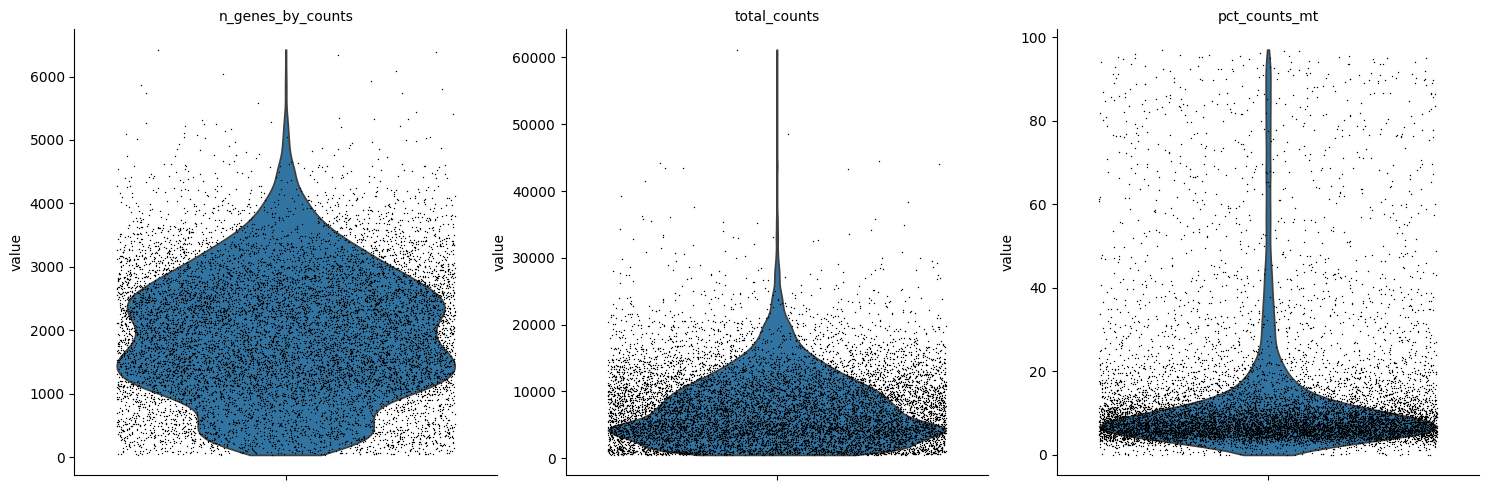

In [11]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

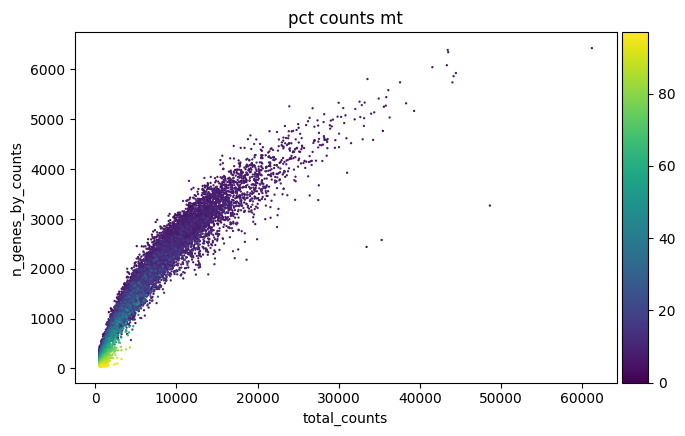

In [12]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

In [13]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=3)

In [14]:
print(adata.shape)
adata = adata[adata.obs.pct_counts_mt < 20, ]
print(adata.shape)

(10962, 22651)
(9547, 22651)


In [15]:
adata = adata[adata.obs.status == "singlet", :].copy()

In [16]:
adata.obs.value_counts("participant")

participant
SQ_Unhealthy_0    2623
SQ_Unhealthy_2    2107
SQ_Healthy_4      1443
SQ_Healthy_0       818
SQ_Unhealthy_3     811
SQ_Unhealthy_1     453
SQ_Healthy_1       374
SQ_Healthy_2       356
SQ_Healthy_3        80
SQ_Unhealthy_4      62
Name: count, dtype: int64

In [ ]:
sc.experimental.pp.recipe_pearson_residuals(adata, batch_key="participant", )

sc.pl.pca(adata, color=["participant",])
plt.show()

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
sc.pl.pca(
    adata,
    color=["participant", "participant", "pct_counts_mt", "pct_counts_mt"],
    dimensions=[(0, 1), (2, 3), (0, 1), (2, 3)],
    ncols=2,
    size=2,
)

In [ ]:
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata, )
sc.pl.umap(adata, color=["participant",])

In [ ]:
sc.tl.leiden(adata, flavor="igraph", n_iterations=2)

In [ ]:
sc.pl.umap(adata, color=["leiden"])

In [ ]:
sc.pl.umap(
    adata,
    color=["leiden", "log1p_total_counts", "pct_counts_mt", "log1p_n_genes_by_counts"],
    wspace=0.5,
    ncols=2,
)

In [ ]:
res_list = [0.02, 0.2, 0.3, 0.4, 0.5, 0.6, 1]
for res in res_list:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:
leiden_resolutions = [f"leiden_res_{res:4.2f}" for res in res_list]

In [ ]:
sc.pl.umap(
    adata,
    color=leiden_resolutions,
    ncols=3,
    legend_loc="on data",
)

In [ ]:
# print(adata.shape)
# adata = adata[adata.obs.pct_counts_mt < 20, ]
# print(adata.shape)

In [ ]:
leiden_clusters = "leiden_res_0.40"

In [ ]:
adata.layers["counts"] = adata.X.copy()

In [ ]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)

In [ ]:
sc.tl.rank_genes_groups(adata, groupby=leiden_clusters, method="wilcoxon")

In [ ]:
sc.pl.rank_genes_groups_dotplot(adata, groupby=leiden_clusters, standard_scale="var", n_genes=5)

In [ ]:
marker_genes = {
    "CD14+ Mono": ["FCN1", "CD14"],
    "Endothelial": ["VWF", ],
    "Myofibroblasts": ["ACTA2", ],
    "Mesothelial": ["MSLN",],
    "APC": ["PI16", ],
    "FAP": ["PDGFRA", "PDGFRB", "DPP4", "IGFBP2", "IGFBP6"],
    # "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # Note: DMXL2 should be negative
    # "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    # "Erythroblast": ["MKI67", "HBA1", "HBB"],
    # Note HBM and GYPA are negative markers
    # "Proerythroblast": ["CDK6", "SYNGR1", "HBM", "GYPA"],
    "NK": ["FCGR3A", "KLRG1", "FCER1G"], # , "GNLY", "NKG7", "CD247", "TYROBP", 
    "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    # "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # Note IGHD and IGHM are negative markers
    "B cells": [
        "CD19",
        "CD79A",
        # "COL4A4",
        # "PRDM1",
        # "IRF4",
        # "PAX5",
        # "BCL11A",
        # "BLK",
        # "IGHD",
        # "IGHM",
    ], #"MS4A1",
    "Plasma cells": ["JCHAIN", ], #"MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC", 
    # Note PAX5 is a negative marker
    # "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    "T naive": ["LEF1", "CCR7", "TCF7"],
    "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
    "T cells": ["CD3E",],
    "Immune": ["PTPRC", ]
}


In [ ]:
sc.pl.dotplot(adata, marker_genes, groupby=leiden_clusters, standard_scale="var")

In [ ]:
sc.pl.umap(
    adata,
    color=leiden_clusters,
    ncols=3,
    legend_loc="on data",
)

In [ ]:
labels = {
    '0': "ECs",
    '1': "Myofibroblasts",
    '2': "FAPs",
    "3": "Myeloid cells",
    "4": "Mesothelial",
    "5": "T cells",
    "6": "IGFBP2+ cells",
    "7": "NK cells",
    "8": "APCs",
    "9": "B cells",
    "10": "Plasma cells",
}

In [ ]:
adata.obs["cell_type"] = [labels[cluster] for cluster in adata.obs[leiden_clusters]]

In [ ]:
sc.pl.umap(
    adata,
    color=["cell_type", "disease"],
    ncols=3,
    legend_loc="on data",
)

In [ ]:
adata.obs["cd45"] = "neg"
adata.obs.loc[adata.obs.cell_type.isin(["Myeloid cells", "T cells", "NK cells", "B cells", "Plasma cells"]), "cd45"] = "pos"

In [ ]:
adata.write(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))

In [ ]:
dc_cluster_genes = sc.get.rank_genes_groups_df(adata, group="7").head(5)["names"]
sc.pl.umap(
    adata,
    color=[*dc_cluster_genes, leiden_clusters],
    legend_loc="on data",
    frameon=False,
    ncols=3,
)

# Fine celltypes Immune non Myeloid

In [ ]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))

In [ ]:
adata = adata_all[(adata_all.obs.cd45 == "pos") & (adata_all.obs.cell_type != "Myeloid cells"),:].copy()

In [ ]:
adata.X = adata.layers["counts"].copy()

In [ ]:
import numpy as np

def f_NB(x, a):
  return x + a * x**2

def mean_var_plot(adata, fit_NB=False, fit_poly=False, log=True,
                  xlim=None, ylim=None):
  from scipy.optimize import curve_fit

  variances = np.var(adata.X.toarray(), axis=0)
  means = adata.X.mean(axis=0).A[0][variances > 0]
  variances = variances[variances > 0]
  lim_min = min(np.min(means), np.min(variances))
  lim_max = max(np.max(means), np.max(variances))
  fig, ax = plt.subplots(figsize=(4, 4))
  ax.plot([lim_min - 0.5, lim_max + 0.5], [lim_min - 0.5, lim_max + 0.5],
          linewidth=1, color="grey", label="")
  sns.scatterplot(x=means, y=variances, ax=ax, linewidth=0, s=3)
  if fit_NB:
    popt_NB, _ = curve_fit(f_NB, means, variances)
    fit_line_NB = np.array(range(int(lim_max))) * 0.01
    ax.plot(fit_line_NB, f_NB(fit_line_NB, *popt_NB), color="red", 
            label="{:.2f}".format(popt_NB[0]))
  ax.set_ylabel("Variance")
  ax.set_xlabel("Mean")
  if log:
    ax.set_xscale("log")
    ax.set_yscale("log")
  if not(xlim is None):
    ax.set_xlim(left=xlim[0], right=xlim[1])
  else:
    ax.set_xlim(left=0, right=lim_max)
  if not(ylim is None):
    ax.set_ylim(bottom=ylim[0], top=ylim[1])
  else:
    ax.set_ylim(bottom=0, top=lim_max)
  ax.legend()
     


In [ ]:
mean_var_plot(adata, fit_NB=True)

In [ ]:
sc.settings.verbosity = 3

In [ ]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=20)

In [ ]:
adata.obs.value_counts("participant")

In [ ]:
sc.pp.highly_variable_genes(adata, batch_key="participant", flavor="seurat_v3") #, n_top_genes=2000)


In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pl.pca(adata, color=["participant",])
plt.show()

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50) #, log=True)

In [ ]:
sc.pp.neighbors(adata, n_pcs=30, n_neighbors=15)
sc.tl.umap(adata, )
sc.pl.umap(adata, color=["participant", "cell_type", "disease"])

In [ ]:
res_list = [0.7, 0.8, 0.9, 1] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
for res in res_list:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:
leiden_resolutions = [f"leiden_res_{res:4.2f}" for res in res_list]

In [ ]:
sc.pl.umap(
    adata,
    color=leiden_resolutions,
    ncols=3,
    legend_loc="on data",
)

In [ ]:
leiden_clusters = "leiden_res_1.00"

In [ ]:
sc.tl.rank_genes_groups(adata, groupby=leiden_clusters, method="wilcoxon")

In [ ]:
# adata_sub = adata[adata.obs[leiden_clusters].isin(["0", "5", "9"]),].copy()
# adata_sub.obs[leiden_clusters] = pd.Categorical(adata_sub.obs[leiden_clusters], categories=adata_sub.obs[leiden_clusters].unique())
# sc.tl.dendrogram(adata_sub, groupby=leiden_clusters)
# # sc.tl.rank_genes_groups(adata_sub, groupby=leiden_clusters, method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(adata, groupby=leiden_clusters, standard_scale="var", n_genes=5, )

In [ ]:
marker_genes = {
    # "CD14+ Mono": ["FCN1", "CD14"],
    # "CD16+ Mono": ["TCF7L2", "FCGR3A", "LYN"],
    # # Note: DMXL2 should be negative
    # "cDC2": ["CST3", "COTL1", "LYZ", "DMXL2", "CLEC10A", "FCER1A"],
    # "NK": ["FCGR3A", "KLRG1", "FCER1G"], # , "GNLY", "NKG7", "CD247", "TYROBP", 
    # "ILC": ["ID2", "PLCG2", "GNLY", "SYNE1"],
    # "Naive CD20+ B": ["MS4A1", "IL4R", "IGHD", "FCRL1", "IGHM"],
    # # Note IGHD and IGHM are negative markers
    # "B cells": [
    #     "CD19",
    #     "CD79A",
    #     "COL4A4",
    #     "PRDM1",
    #     "IRF4",
    #     "PAX5",
    #     "BCL11A",
    #     "BLK",
    #     "IGHD",
    #     "IGHM",
    # ], #"MS4A1",
    # "Plasma cells": ["JCHAIN", "MZB1", "HSP90B1", "FNDC3B", "PRDM1", "IGKC"], 
    # # Note PAX5 is a negative marker
    # "Plasmablast": ["XBP1", "PRDM1", "PAX5"],
    # "CD4+ T": ["CD4", "IL7R", "TRBC2"],
    # "CD8+ T": ["CD8A", "CD8B", "GZMK", "GZMA", "CCL5", "GZMB", "GZMH", "GZMA"],
    # "T naive": ["LEF1", "CCR7", "TCF7"],
    # "pDC": ["GZMB", "IL3RA", "COBLL1", "TCF4"],
    # "T cells": ["CD3E",],
    # "Tcell": ["TRAC", "TRDC", "TRGC1", "TRGC2", "CD3E", "CD4", "CD8A", "CD8B", "LEF1", "IL7R", "PRF1", "GZMB", "EML4"],
    # "B cells": ["JCHAIN", "CD79A"],
    # "NK cells": ["FCGR3A", "FCER1G", "FGFBP2", "KLRC1", "KLRC2", "XCL2", "PRF1", "GNLY", "TBX21", "S1PR5", "AQP3"],
    # "Immune": ["PTPRC", "EML4", "JCHAIN", "FCER1G", "FCGR3A", "TRGC2", "CD8A", "LEF1", "IL7R", "CD3E", "CD79A", "FOXP3", "CTLA4", "THEMIS", "KLRD1", "CD96", "MS4A1", "CSF3R", "CLEC4C", "XBP1", "PRDM1", "PAX5", "TCF7", "CD14", 
                # "ZNF683", "IL1RL1", "AFF3", "VEGFA", "PTGS2", "AQP3", "HPGD", "GATA3", "KIT", "SELL", "KLRB1", "TRDC", "IL2"],
    "T_lineage": ["CD3D", "TRAC"],
    "NK_lineage": ["KLRD1", "NCAM1"],
     # ---- T CELL LINEAGE ----
    "T_cells_general": [
        "CD3D", "CD3E", "TRAC"
    ],

    # ---- CD8 T CELLS ----
    "CD8_effector": [
        "CD8A", "GZMB", "PRF1", "NKG7", "IFNG", "KLRG1", "CX3CR1", "TCF7"
    ],

    "CD8_exhausted": [
        "PDCD1", "LAG3", "TIGIT", "HAVCR2", "TOX"
    ],

    "CD8_TRM_like": [
        "CD69", "CXCR6", "ZNF683", "ITGAE", "RGS1"
    ],

    # ---- CD4 T CELLS ----
    "CD4_effector_memory": [
        "CD4", "IL7R", "CCR6", "CXCR3", "LTB", "CCR7", "SELL", "TCF7", "NR4A1", "ENTPD1"
    ],

    "Treg_adipose": [
        "FOXP3", "IL2RA", "CTLA4", "TNFRSF18", "PPARG"
    ],

    # ---- INNATE / UNCONVENTIONAL T CELLS ----
    "gamma_delta_T": [
        "TRDC", "TRGC1", "TRGC2", "KLRB1", "RORC"
    ],

    "MAIT_cells": [
        "KLRB1", "SLC4A10", "IL18R1", "RORC"
    ],

    # ---- NK CELLS ----
    "NK_cytotoxic": [
        "FCGR3A", "NCAM1", "NKG7", "GNLY", "GZMB"
    ],

    "NK_cytokine_skewed": [
        "NCAM1", "XCL1", "GZMK", "KLRC1", "IL7R"
    ],

    "NK_ILC1_like": [
        "ITGA1", "CXCR6", "TBX21", "EOMES", "ZNF683"
    ],

    # ---- B CELLS ----
    "B_naive": [
        "MS4A1", "IGHD", "TCL1A", "CD79A", "FCER2"
    ],

    "B_memory": [
        "CD27", "MS4A1", "IGHG1", "IGHG3", "BANK1"
    ],

    "Plasma_cells": [
        "XBP1", "PRDM1", "MZB1", "JCHAIN", "SDC1"
    ],

    "CM T cells": ["LEF1", "BACH2", "SATB1", "KLF2"],
    "Cluster 15": ["ITGAE", "CXCR6", "CD69", "ZNF683", "CXCR5", "BCL6", "PDCD1", "ICOS", "MAF", "FOS", "JUN", "EGR1", "CD69", "HLA-DRA", "CD38", "TBX21", "IFNG",   # Th1
 "RORC", "IL17A",   # Th17
 "GATA3", "TOX", "ENTPD1", "LAG3", "TIGIT"]            # Tfh
    # "Additional": ["CCR6", "TIGIT", "KLRB1", "CD2", "CD28", "CRTAM", "GZMB", "GZMH", "IFNG", "KLRC2", "CD200R1", "CD8A", "CD8B", "TRGC2", "FCGR3A", "CD3E", "CD4", "IL7R", "CCL5", "CXCR3", "TBX21", "EOMES", "GATA3", "CCR4", "IL17A", "RORC", "CTSH", "CCL20", "CD200", "TOX", "TOX2", "CXCR5", "ITGB1", "FGFBP2", "GNLY", "CD7", "AREG"],
}


In [ ]:
sc.pl.stacked_violin(adata, marker_genes, groupby=leiden_clusters, dendrogram=True)

In [ ]:
sc.pl.dotplot(adata, marker_genes, groupby=leiden_clusters, standard_scale="var")

In [ ]:
labels = {
   
    "0": "CD4+ T cells",
    "1": "GD T cells",
    "2": "Effector CD8+ T cells",
    "3": "CD8+ T cells",
    "4": "CD4+ T cells",
    "5": "mNK3 cells",
    "6": "mNK1 cells",
    "7": "CD8+ TRM",
    "8": "CD4+ T cells",
    "9": "mNK2 cell",
    "10": "B cells",
    "11": "Plasma cells",
    "12": "pDCs",
    "13": "NA CD4+ T cells",
    "14": "CM CD4+ T cells",
    "15": "EM CD4+ T cells"
}

In [ ]:
sc.pl.umap(
    adata,
    color=[leiden_clusters, "cell_type2", "disease"],
    ncols=3,
    legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
sc.pl.umap(
    adata,
    color=[leiden_clusters, "cell_type1", "disease"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata_healthy = adata[adata.obs.disease == "Healthy",:]
adata_unhealthy = adata[adata.obs.disease == "Unhealthy",:]
sc.pl.umap(
    adata_healthy,
    color=[leiden_clusters, "cell_type1"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)
sc.pl.umap(
    adata_unhealthy,
    color=[leiden_clusters, "cell_type1"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata.write(os.path.join(INPUT_DIR, "sc", 'omentum_immune_lympho_annotated.h5ad'))

In [ ]:
adata.obs["cell_type2"] = [labels[cluster] for cluster in adata.obs[leiden_clusters]]

# Fine celltypes Immune Myeloid

In [ ]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))

In [ ]:
adata_na = adata_all[adata_all.obs.cell_type == "Myeloid cells",:].copy()

In [ ]:
adata_na.X = adata_na.layers["counts"].copy()

In [ ]:
sc.pp.filter_cells(adata_na, min_genes=100)
sc.pp.filter_genes(adata_na, min_cells=3)

In [ ]:
adata_na.obs.value_counts("participant")

In [ ]:
adata = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_immune_myeloid_half_annotated.h5ad'))

In [ ]:
assert (adata_na.obs_names == adata.obs_names).all()

In [ ]:
adata_na.obs = adata.obs.copy()

In [ ]:
adata_na.uns = adata.uns.copy()
adata_na.obsm = adata.obsm.copy()

In [ ]:
sc.pp.normalize_total(adata_na)
# Logarithmize the data
sc.pp.log1p(adata_na)

In [ ]:
sc.pp.highly_variable_genes(adata, batch_key="participant", flavor="seurat_v3") #, n_top_genes=2000)


In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pl.pca(adata, color=["participant",])
plt.show()

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50) #, log=True)

In [ ]:
sc.pp.neighbors(adata, n_pcs=20, n_neighbors=15)
sc.tl.umap(adata, )
sc.pl.umap(adata, color=["participant", "cell_type", "disease"])

In [ ]:
res_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
for res in res_list:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:
leiden_resolutions = [f"leiden_res_{res:4.2f}" for res in res_list]

In [ ]:
sc.pl.umap(
    adata,
    color=leiden_resolutions,
    ncols=3,
    legend_loc="on data",
    # add_outline=True,
    legend_fontoutline=3
)

In [ ]:
leiden_clusters = "leiden_res_0.40"

In [ ]:
sc.tl.rank_genes_groups(adata_na, groupby=leiden_clusters, method="wilcoxon")

In [ ]:
# adata_sub = adata[adata.obs[leiden_clusters].isin(["0", "5", "9"]),].copy()
# adata_sub.obs[leiden_clusters] = pd.Categorical(adata_sub.obs[leiden_clusters], categories=adata_sub.obs[leiden_clusters].unique())
sc.tl.dendrogram(adata_na, groupby=leiden_clusters)
# # sc.tl.rank_genes_groups(adata_sub, groupby=leiden_clusters, method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(adata_na, groupby=leiden_clusters, standard_scale="var", n_genes=15, )

In [ ]:
marker_genes = {
    "all": [
        "CLEC10A", "CLEC9A", "PTPRC", "CD14", "THBS1", "FCGR3A", "TREM2", "LYVE1", "CD9", "TNF", "CCL3L1", "MRC1", "CD68",
        "CADM1", "FCER1A", "CSF3R", "ITGAM", "MPO", "FUT4", "RGS13", "PECAM1", "VWF", "ACTA2", "RGS5", "PDGFRA", "COL1A1", "DCN", "TUBB3"],
    "mast_cell_core": [
    "KIT",        # CD117
    "TPSAB1",     # tryptase alpha/beta
    "TPSB2",      # tryptase beta
    #"CPA3",       # carboxypeptidase A3
   # "MS4A2",      # FcεRI beta chain
    #"HDC",        # histidine decarboxylase
    "GATA2",      # lineage TF
    "MITF",        # mast cell differentiation TF
        "CXCR2", "FCGR3B", "MPO", "ELANE", "CSF3R"
],
    
    "monocyte_vs_macrophage": [
    "CD14",
    "CCR2",
    "FCGR3A",
    "HLA-DRA",
    "CD68",
    "C1QA",
    "C1QB",
    "C1QC",
    "MRC1",
    "CD163"
]
}


In [ ]:
adata_na.var.loc[['GATA2', 'KIT', 'TPSAB1', 'TPSB2'],:]  #'CPA3', 'MS4A2', 'HDC', 

In [ ]:
sc.pl.stacked_violin(adata, marker_genes, groupby=leiden_clusters, dendrogram=True)

In [ ]:
sc.pl.dotplot(adata_na, marker_genes, groupby=leiden_clusters, standard_scale="var")

In [ ]:
labels = {
    "0": "PVMs",
    "1": "Neutrophils",
    "2": "LAMs",
    "3": "Monocytes",
    "4": "DC",
    "5": "Mast cells?", #
    "6": "CD9+ ATM"
}

In [ ]:
sc.pl.umap(
    adata_na,
    color=[leiden_clusters, "cell_type1", "disease"],
    ncols=3,
    legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata_na.obs.columns

In [ ]:
sc.pl.umap(
    adata_na,
    color=[leiden_clusters, "pct_counts_mt", "n_genes_by_counts"],
    ncols=3,
    legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata_healthy = adata[adata.obs.disease == "Healthy",:]
adata_unhealthy = adata[adata.obs.disease == "Unhealthy",:]
sc.pl.umap(
    adata_healthy,
    color=[leiden_clusters, "cell_type"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)
sc.pl.umap(
    adata_unhealthy,
    color=[leiden_clusters, "cell_type"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata.obs["cell_type1"] = [labels[cluster] for cluster in adata.obs[leiden_clusters]]

In [ ]:
adata.write(os.path.join(INPUT_DIR, "sc", 'omentum_immune_myeloid_half_annotated.h5ad'))

# Fine celltypes non-Immune

In [ ]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))

In [ ]:
adata = adata_all[adata_all.obs.cd45 == "neg",:].copy()

In [ ]:
adata.X = adata.layers["counts"].copy()

In [ ]:
sc.pp.filter_cells(adata, min_genes=100)
sc.pp.filter_genes(adata, min_cells=10)

In [ ]:
adata.obs.value_counts("participant")

In [ ]:
sc.pp.highly_variable_genes(adata, batch_key="participant", flavor="seurat_v3") #, n_top_genes=2000)


In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
sc.pp.normalize_total(adata)
# Logarithmize the data
sc.pp.log1p(adata)
sc.pp.pca(adata)
sc.pl.pca(adata, color=["participant",])
plt.show()

In [ ]:
sc.pl.pca_variance_ratio(adata, n_pcs=50) #, log=True)

In [ ]:
sc.pp.neighbors(adata, n_pcs=20, n_neighbors=15)
sc.tl.umap(adata, )
sc.pl.umap(adata, color=["participant", "cell_type", "disease"])

In [ ]:
res_list = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] #[0.1, 0.2, 0.3, 0.4, 0.5, 0.6]
for res in res_list:
    sc.tl.leiden(adata, key_added=f"leiden_res_{res:4.2f}", resolution=res, flavor="igraph")

In [ ]:
leiden_resolutions = [f"leiden_res_{res:4.2f}" for res in res_list]

In [ ]:
sc.pl.umap(
    adata,
    color=leiden_resolutions,
    ncols=3,
    legend_loc="on data",
    # add_outline=True,
    legend_fontoutline=3
)

In [ ]:
leiden_clusters = "leiden_res_0.50"

In [ ]:
sc.tl.rank_genes_groups(adata, groupby=leiden_clusters, method="wilcoxon")

In [ ]:
# adata_sub = adata[adata.obs[leiden_clusters].isin(["0", "5", "9"]),].copy()
# adata_sub.obs[leiden_clusters] = pd.Categorical(adata_sub.obs[leiden_clusters], categories=adata_sub.obs[leiden_clusters].unique())
sc.tl.dendrogram(adata, groupby=leiden_clusters)
# # sc.tl.rank_genes_groups(adata_sub, groupby=leiden_clusters, method="wilcoxon")

sc.pl.rank_genes_groups_dotplot(adata, groupby=leiden_clusters, standard_scale="var", n_genes=5, )

In [ ]:
marker_genes = {
    "mesothelial_markers": [
    "FN1","COL1A1","COL3A1","TAGLN"
],
    "MMT": ["SNAI1","SNAI2","ZEB1","ZEB2","TWIST1","PRRX1", "OCLN","TJP1","CLDN4", "CDH1", "FN1", "ACTA2"]
}


In [ ]:
sc.pl.stacked_violin(adata, marker_genes, groupby=leiden_clusters, dendrogram=True)

In [ ]:
sc.pl.dotplot(adata, marker_genes, groupby=leiden_clusters, standard_scale="var")

In [ ]:
labels = {
    "0": "VECs",
    "1": "Myofibroblasts",
    "2": "PI16+ APC",
    "3": "Mesothelial cells",
    "4": "FAP2",
    "5": "FAP1",
    "6": "LECs",
    "7": "IGFBP2+",
    "8": "FAP3",
    "9": "MMT cells",
    "10": "Mesothelial cells"
}

In [ ]:
sc.pl.umap(
    adata,
    color=[leiden_clusters, "cell_type1", "disease"],
    ncols=3,
    legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata_healthy = adata[adata.obs.disease == "Healthy",:]
adata_unhealthy = adata[adata.obs.disease == "Unhealthy",:]
sc.pl.umap(
    adata_healthy,
    color=[leiden_clusters, "cell_type"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)
sc.pl.umap(
    adata_unhealthy,
    color=[leiden_clusters, "cell_type"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
adata.obs["cell_type1"] = [labels[cluster] for cluster in adata.obs[leiden_clusters]]

In [ ]:
adata.write(os.path.join(INPUT_DIR, "sc", 'omentum_nonimmune_finely_annotated.h5ad'))

# Combining annotations together

In [ ]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))
adata_lympho = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_immune_lympho_annotated.h5ad'))
adata_myel = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_immune_myeloid_half_annotated.h5ad'))
adata_nonim = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_nonimmune_finely_annotated.h5ad'))

In [ ]:
adata_nonim.obs.value_counts(["cell_type1",]).sort_index()

In [ ]:
adata_all.obs["cell_type1"] = None

adata_all.obs.loc[adata_lympho.obs_names, "cell_type1"] = adata_lympho.obs["cell_type2"].values

adata_all.obs.loc[adata_myel.obs_names, "cell_type1"] = adata_myel.obs["cell_type1"].values

adata_all.obs.loc[adata_nonim.obs_names, "cell_type1"] = adata_nonim.obs["cell_type1"].values

In [ ]:
with pd.option_context('display.max_rows', None):
    print(adata_all.obs.value_counts(["cell_type", "cell_type1"]).sort_index())

In [ ]:
celltypes = {
'ECs': ["VECs", "LECs"],
 'Myofibroblasts': ["Myofibroblasts"],
 'FAPs': ["FAPs", "FAP1", "FAP2", "FAP3"],
 'Myeloid cells': ["PVMs", "Neutrophils", "LAMs", "Monocytes", "DC", "pDCs", "CD9+ ATM", "Mast cells?"],
 'Mesothelial': ["Mesothelial cells", "MMT cells"],
 'T cells': ["CD4+ T cells", "GD T cells", "Effector CD8+ T cells", "CD8+ T cells", "CD8+ TRM", "NA CD4+ T cells", "CM CD4+ T cells", "EM CD4+ T cells"],
 'IGFBP2+ cells': ["IGFBP2+",],
 'NK cells': ["mNK3 cells", "mNK1 cells", "mNK2 cell"],
 'PI16+ APCs': ["PI16+ APCs",],
 'B cells': ["B cells",],
 'Plasma cells': ["Plasma cells",],
}

celltypes_rev = {}

for cell_type, l in celltypes.items():
    for cell_type1 in l:
        celltypes_rev[cell_type1] = cell_type


In [ ]:
# FAPs and APCs cell-types correction
adata_all.obs.loc[adata_all.obs.cell_type == "APCs", "cell_type1"] = "PI16+ APCs"
adata_all.obs.loc[adata_all.obs.cell_type == "FAPs", "cell_type1"] = "FAPs"
adata_all.obs.loc[adata_all.obs.cell_type1.isin(["FAP1", "FAP2", "FAP3"]), "cell_type1"] = "FAPs"
adata_all.obs.loc[adata_all.obs.cell_type1 == "PI16+ APC", "cell_type1"] = "PI16+ APCs"

In [ ]:
adata_all.obs.cell_type1 = adata_all.obs.cell_type1.astype(str)
adata_all.obs.loc[adata_all.obs.cell_type1 == "DC", "cell_type1"] = "cDCs"

In [ ]:
adata_all.obs["cell_type"] = adata_all.obs["cell_type"].astype(str)

for i, row in adata_all.obs.iterrows():
    adata_all.obs.loc[i, "cell_type"] = celltypes_rev[row["cell_type1"]]

In [ ]:
sc.pl.umap(
    adata_all,
    color=["cell_type", "cell_type1"],# "disease"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
marker_genes = {
    "all": ["PI16", "PDGFRA", "PDGFRB", "APOE",]
}

In [ ]:
sc.pl.dotplot(adata_all, marker_genes, groupby="cell_type", standard_scale="var")

In [ ]:
adata_orig = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_broadly.h5ad'))

In [ ]:
sc.pl.umap(
    adata_orig,
    color=["cell_type", ],# "disease"],
    ncols=3,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2
)

In [ ]:
sc.pl.dotplot(adata_orig, marker_genes, groupby="cell_type", standard_scale="var")

In [ ]:
adata_all.obs.value_counts(["cd45", "cell_type"]).sort_index()

In [ ]:
adata_all.write(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_finely.h5ad'))

# Figures

In [42]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_finely.h5ad'))
adata_lympho = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_immune_lympho_annotated.h5ad'))
adata_myel = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_immune_myeloid_half_annotated.h5ad'))
adata_nonim = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_nonimmune_finely_annotated.h5ad'))

In [43]:
adata_all.obs.cell_type1 = adata_all.obs.cell_type1.astype(str)
adata_all.obs.cell_type = adata_all.obs.cell_type.astype(str)

adata_all.obs.loc[adata_all.obs.cell_type1 == "PI16+ APCs", "cell_type1"] = "Pre-adipocytes"
adata_all.obs.loc[adata_all.obs.cell_type == "PI16+ APCs", "cell_type"] = "Pre-adipocytes"

In [44]:
adata_all.obs.value_counts("cell_type")

cell_type
FAPs              6787
T cells           5920
Mesothelial       5009
Myeloid cells     2881
NK cells          1347
Pre-adipocytes    1297
ECs                870
Myofibroblasts     697
IGFBP2+ cells      587
B cells            374
Plasma cells        61
Name: count, dtype: int64

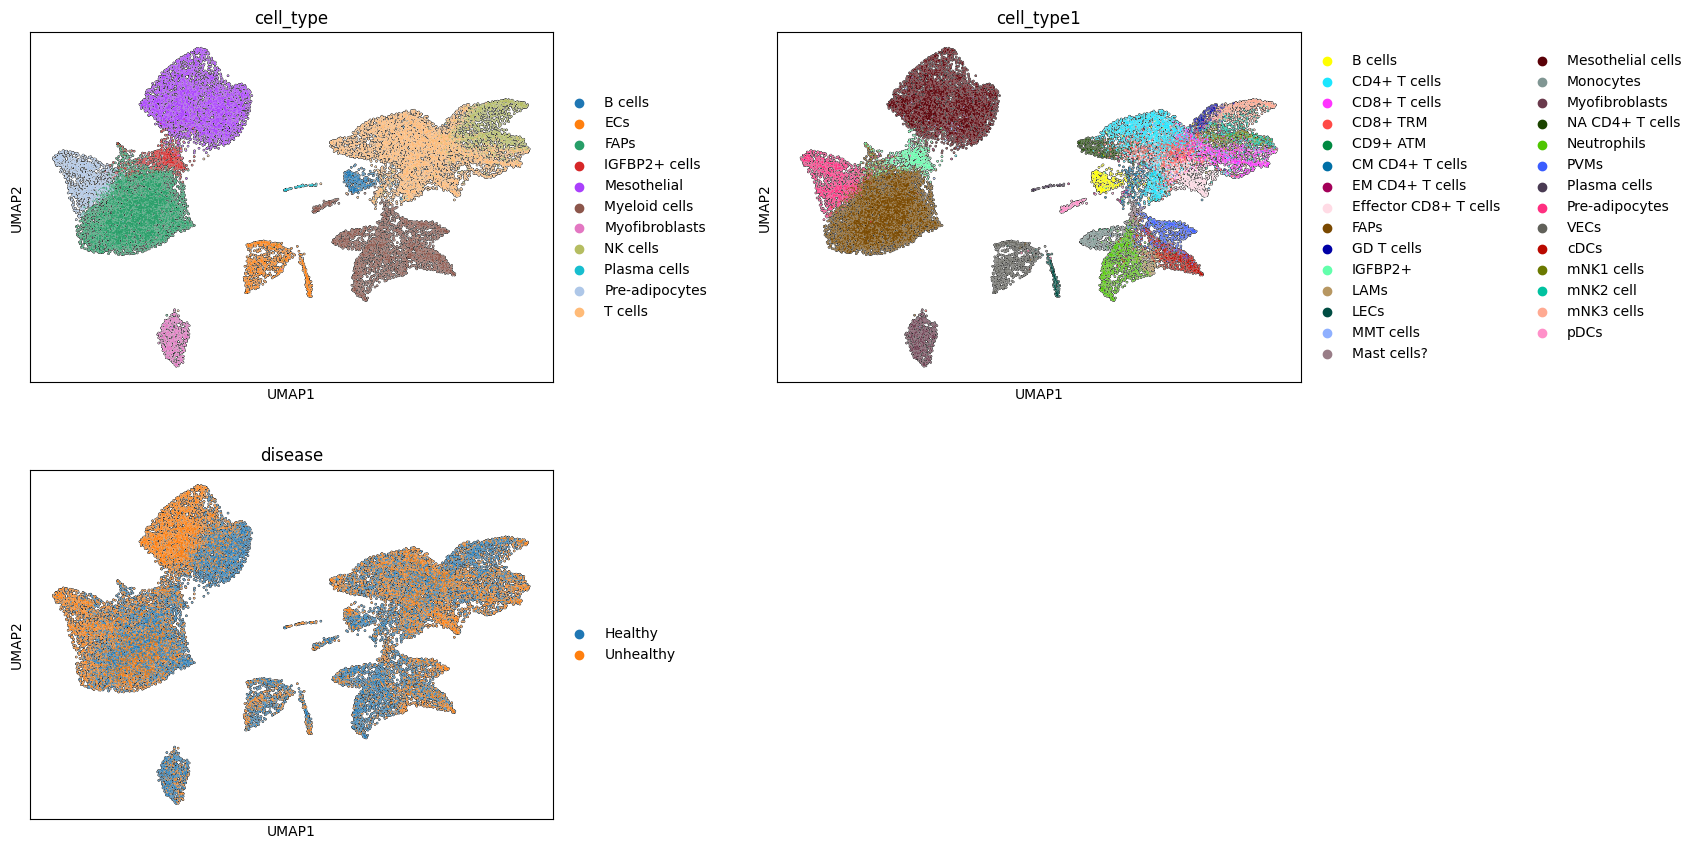

In [45]:
# fig, ax = plt.subplots(figsize=(12, 12))
fig = sc.pl.umap(
    adata_all,
    color=["cell_type", "cell_type1", "disease"],
    ncols=2,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2,
    return_fig=True,
    wspace=0.3
    # ax=ax
)
# fig.tight_layout()

In [46]:
adata_lympho.obs.cell_type1 = adata_lympho.obs.cell_type1.astype(str)
adata_lympho.obs.loc[adata_lympho.obs.cell_type1 == "strange cells", "cell_type1"] = "PLCG2+ cells"

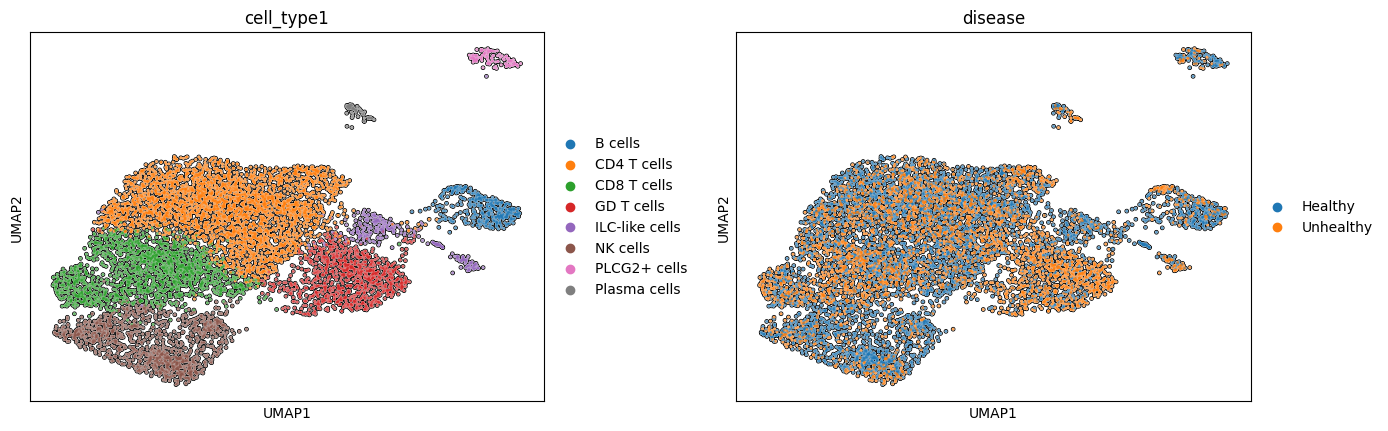

In [47]:
# fig, ax = plt.subplots(figsize=(12, 12))
fig = sc.pl.umap(
    adata_lympho,
    color=["cell_type1", "disease"],
    ncols=2,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2,
    return_fig=True,
    wspace=0.25
    # ax=ax
)
# fig.tight_layout()

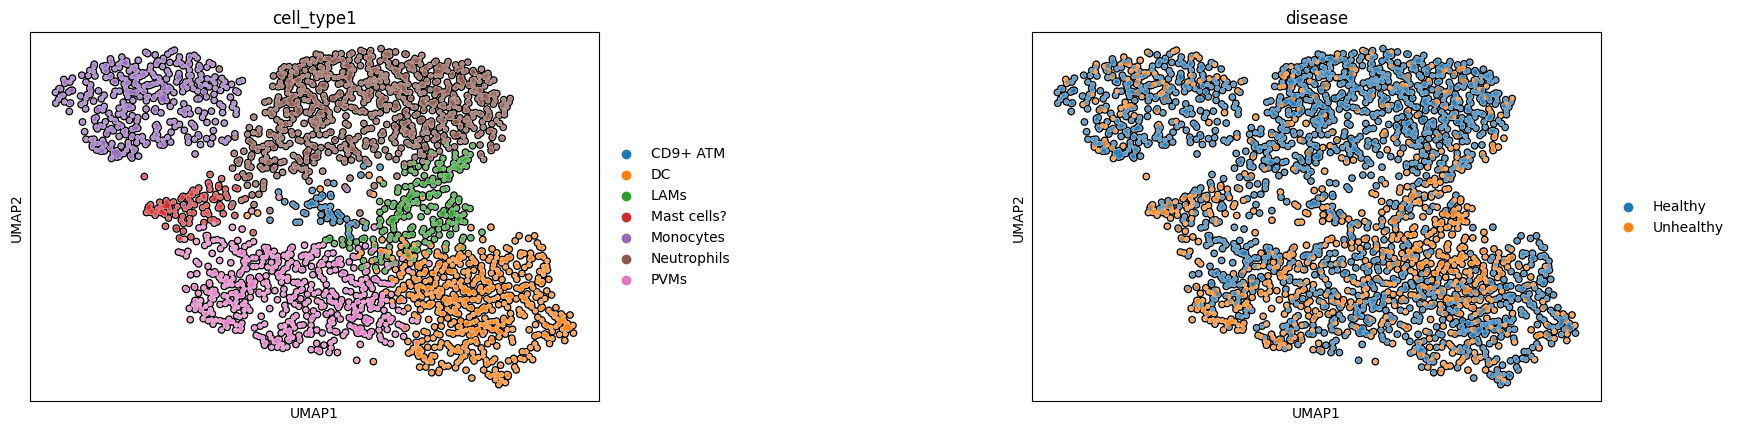

In [48]:
# fig, ax = plt.subplots(figsize=(12, 12))
fig = sc.pl.umap(
    adata_myel,
    color=["cell_type1", "disease"],
    ncols=2,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2,
    return_fig=True,
    wspace=0.6
    # ax=ax
)
# fig.tight_layout()

In [49]:
adata_nonim.obs.cell_type1 = adata_nonim.obs.cell_type1.astype(str)

adata_nonim.obs.loc[adata_nonim.obs.cell_type1 == "PI16+ APC", "cell_type1"] = "Pre-adipocytes"

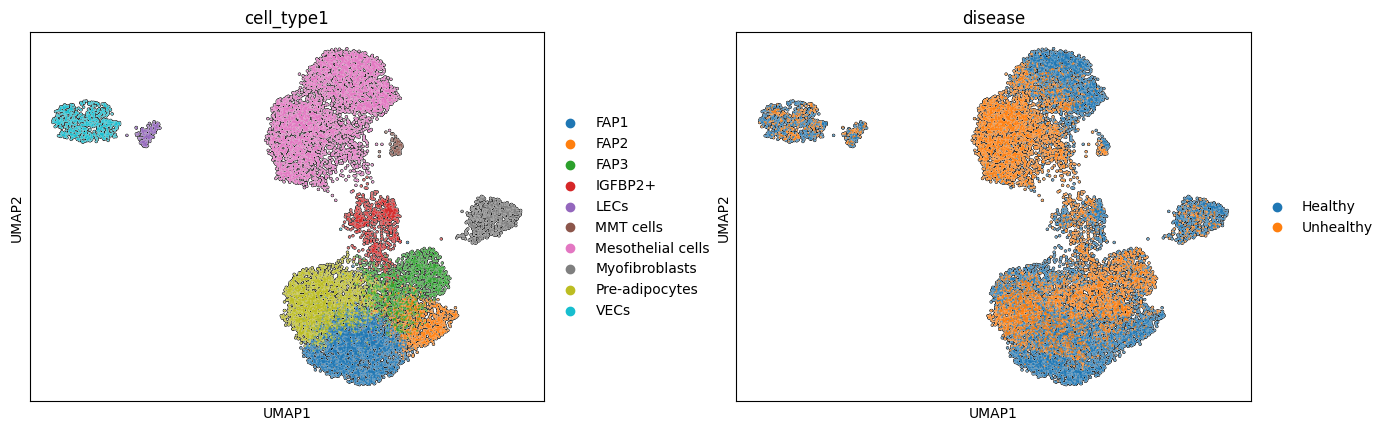

In [50]:
# fig, ax = plt.subplots(figsize=(12, 12))
fig = sc.pl.umap(
    adata_nonim,
    color=["cell_type1", "disease"],
    ncols=2,
    # legend_loc="on data",
    add_outline=True,
    legend_fontoutline=2,
    return_fig=True,
    wspace=0.25
    # ax=ax
)
# fig.tight_layout()

In [51]:
adata_all.write(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_finely.h5ad'))
adata_lympho.write(os.path.join(INPUT_DIR, "sc", 'omentum_immune_lympho_annotated.h5ad'))
adata_myel.write(os.path.join(INPUT_DIR, "sc", 'omentum_immune_myeloid_half_annotated.h5ad'))
adata_nonim.write(os.path.join(INPUT_DIR, "sc", 'omentum_nonimmune_finely_annotated.h5ad'))

## Counts by participant by cell-type

In [59]:
adata_all = sc.read_h5ad(os.path.join(INPUT_DIR, "sc", 'omentum_reannotated_finely.h5ad'))
tissue = "Omentum"

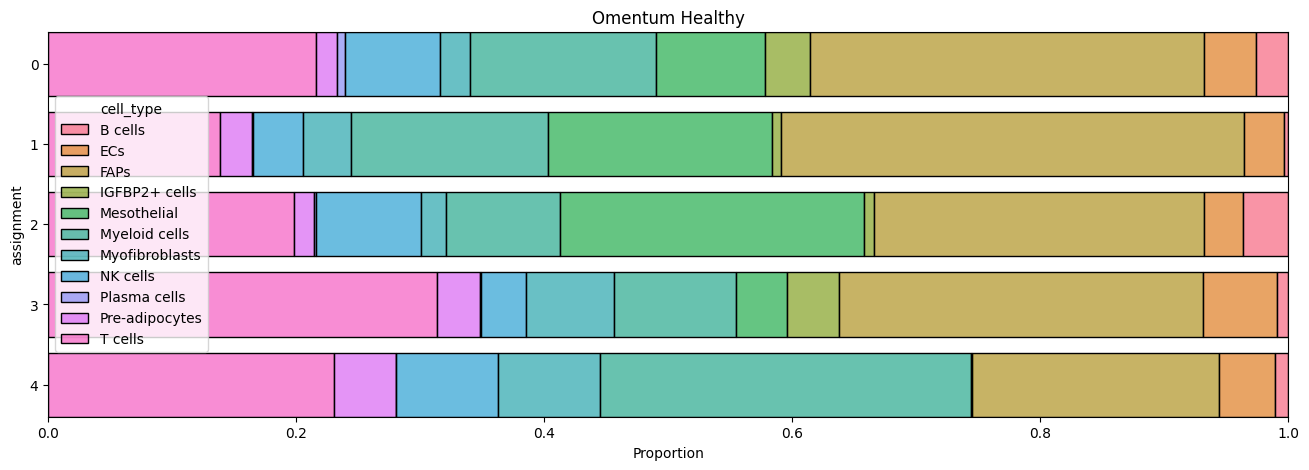

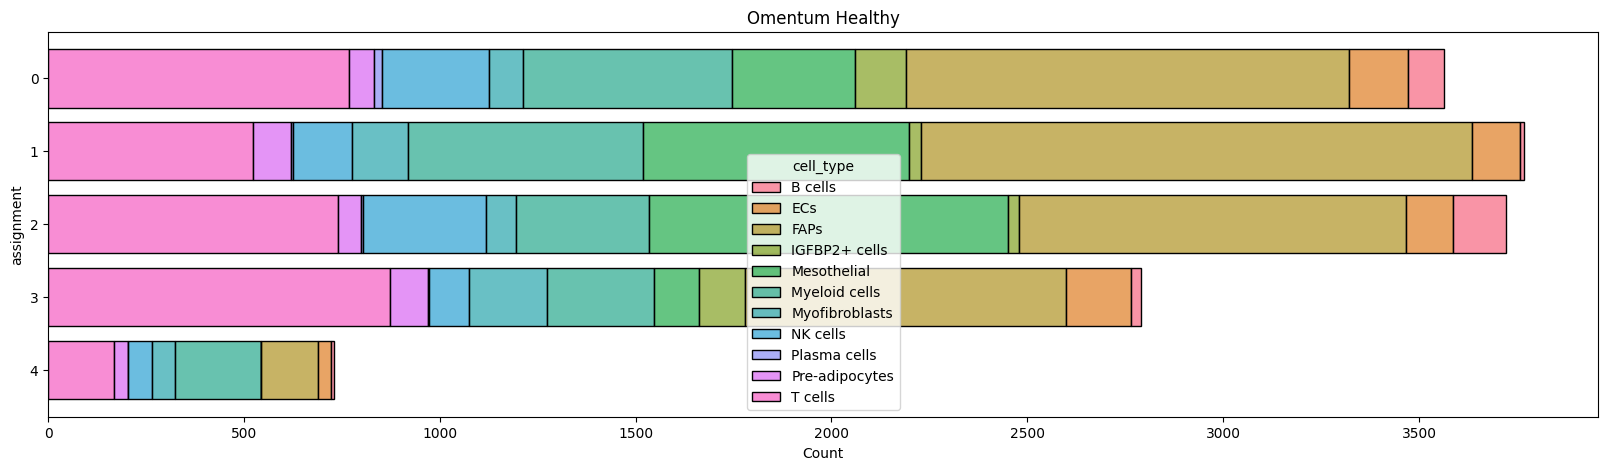

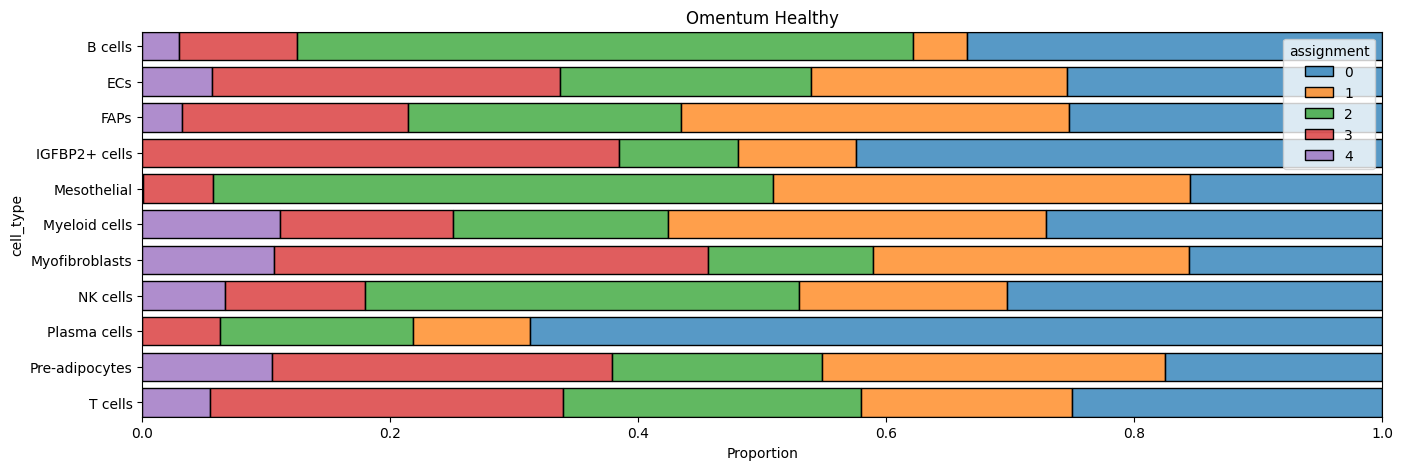

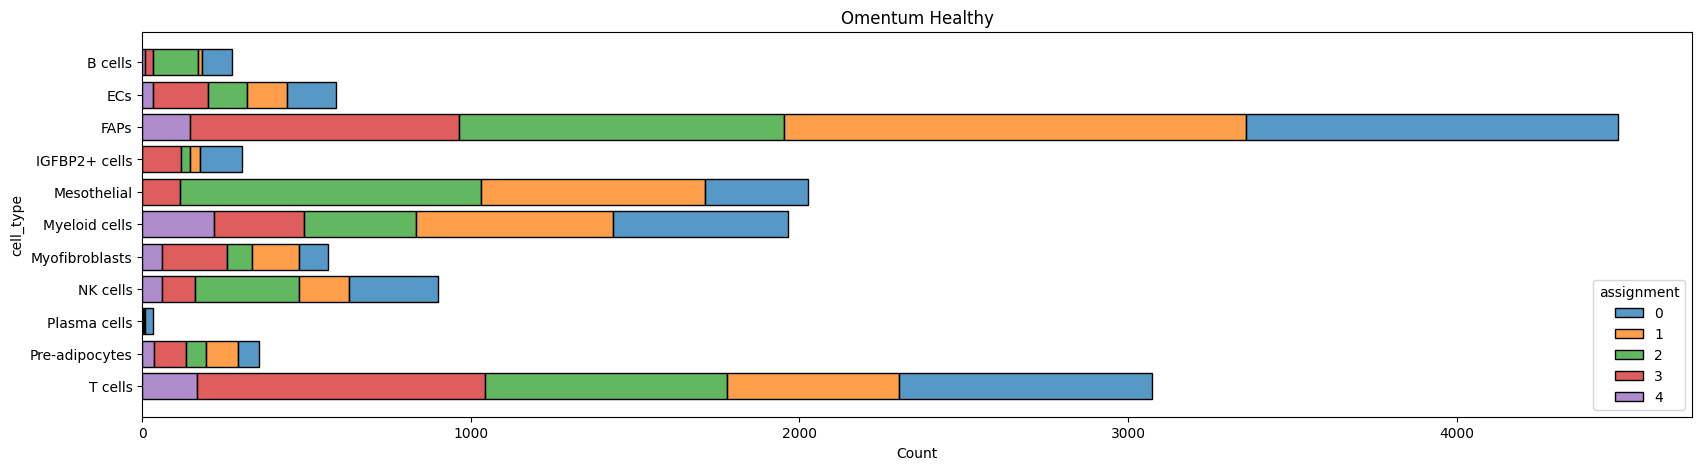

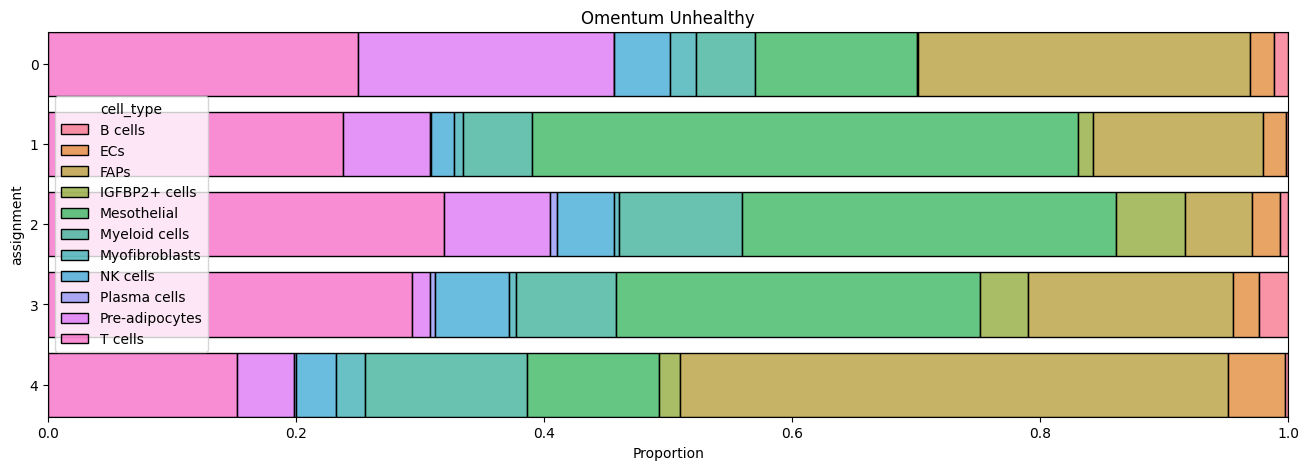

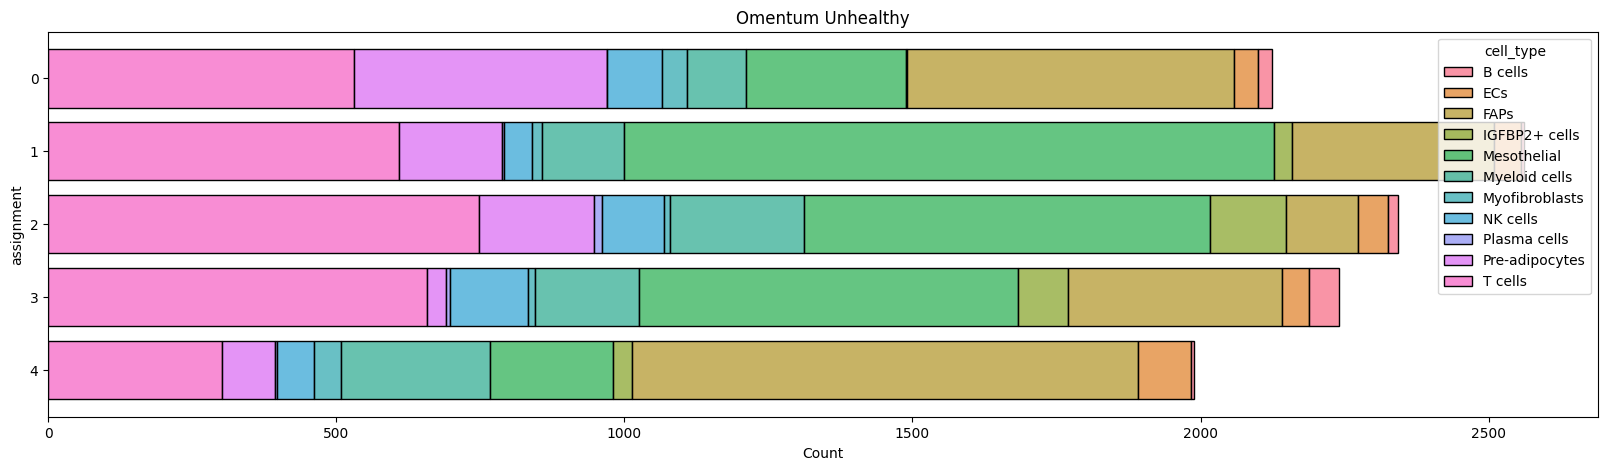

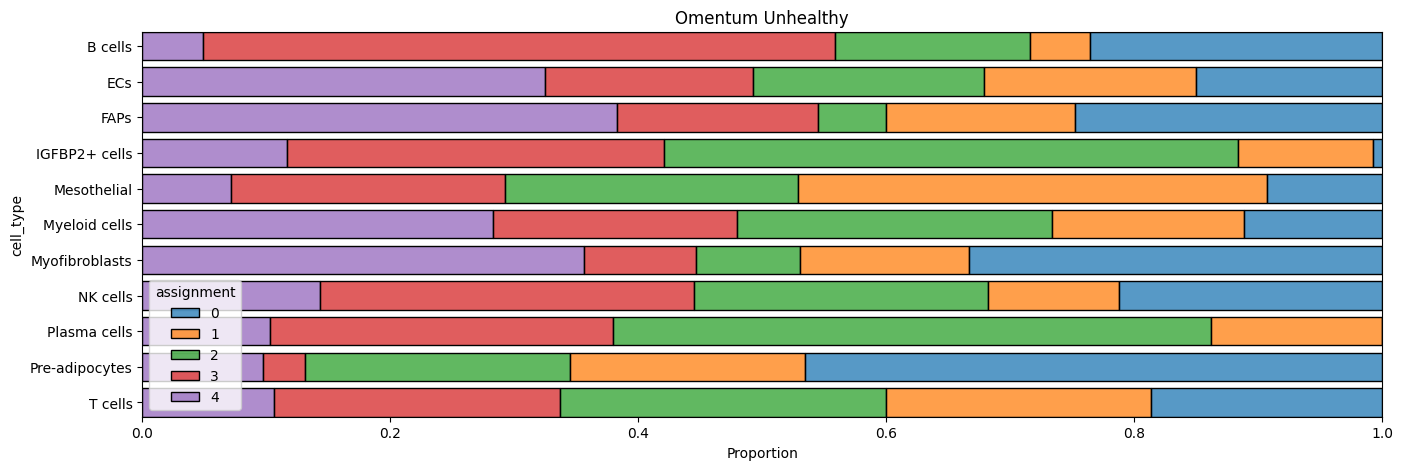

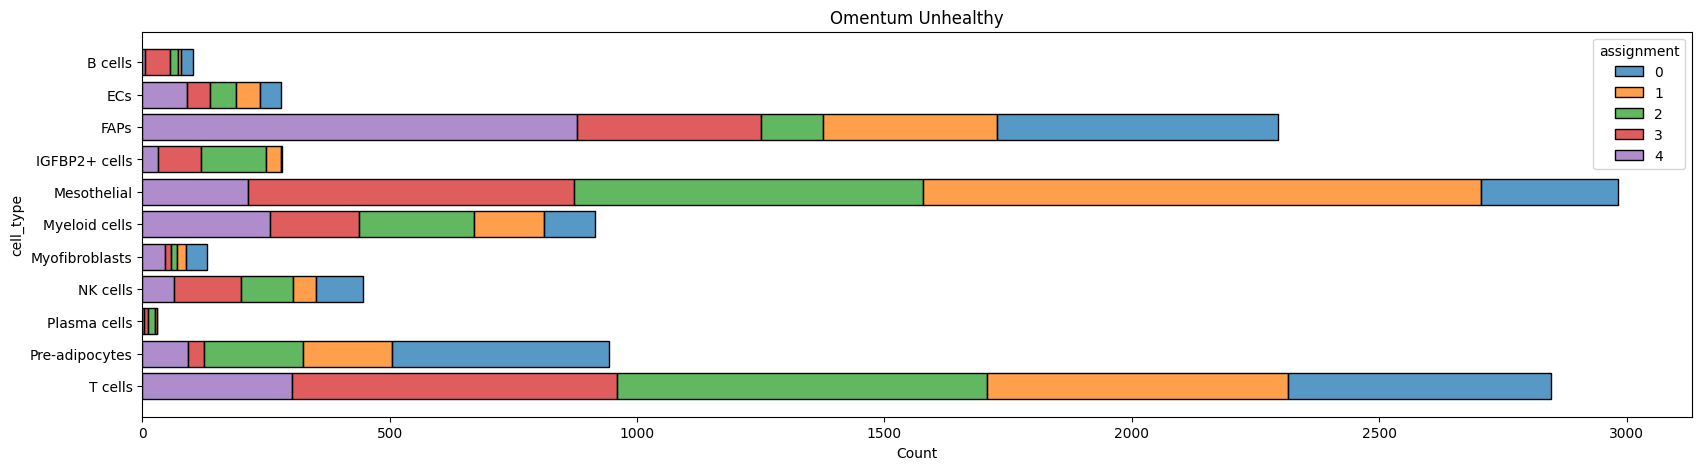

In [60]:
for disease in ["Healthy", "Unhealthy"]:
    
    adata = adata_all[adata_all.obs.disease == disease,:]
    title = f'{tissue} {disease}'
    
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue="cell_type",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue="cell_type",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y="cell_type", hue="assignment",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y="cell_type", hue="assignment",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

#### CD45+

In [62]:
adata_45 = adata_all[adata_all.obs.cd45 == "pos",:]
hue = "cell_type1"
tissue = "Omentum CD45+"

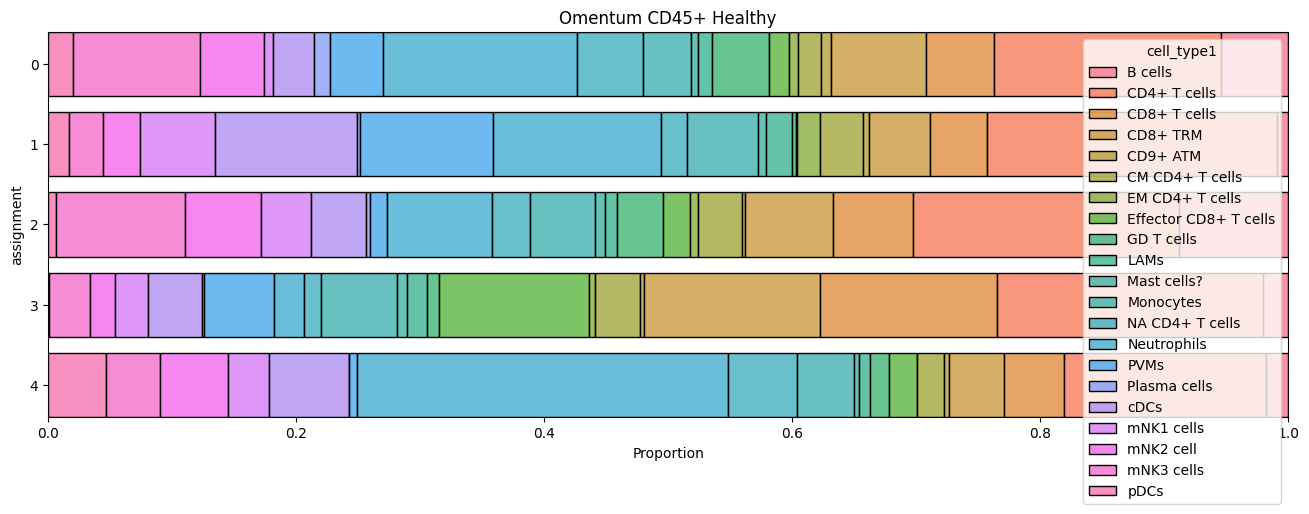

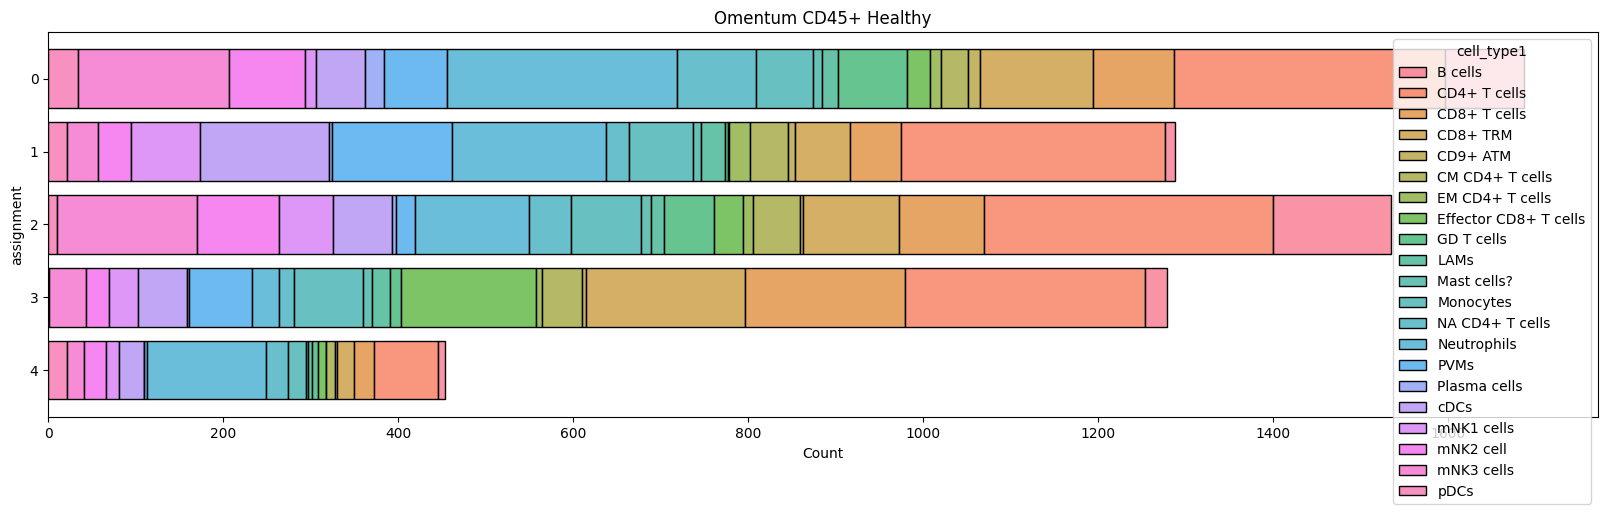

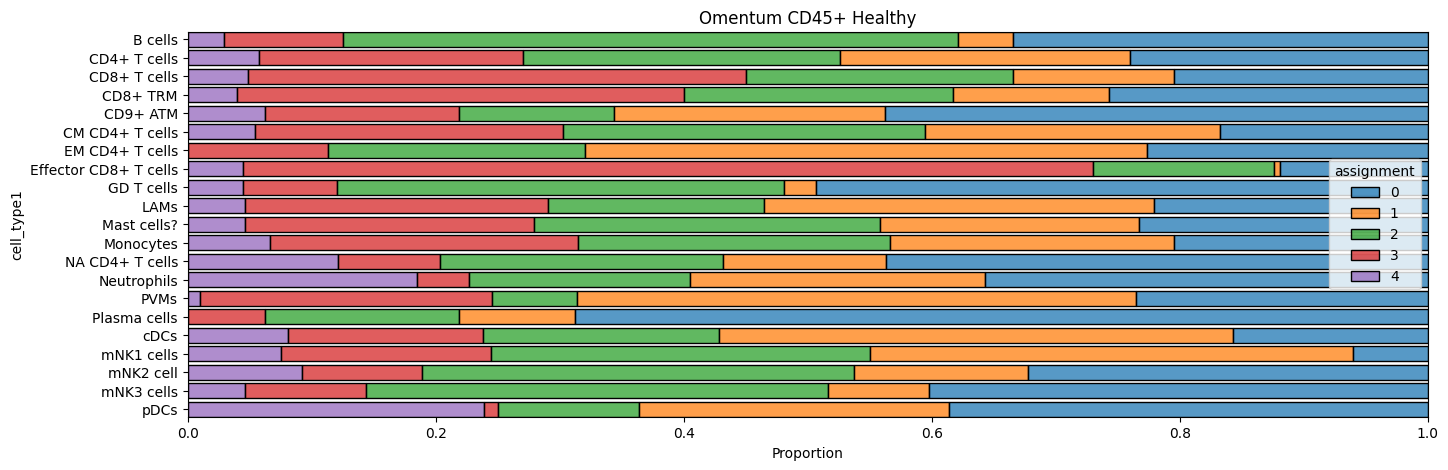

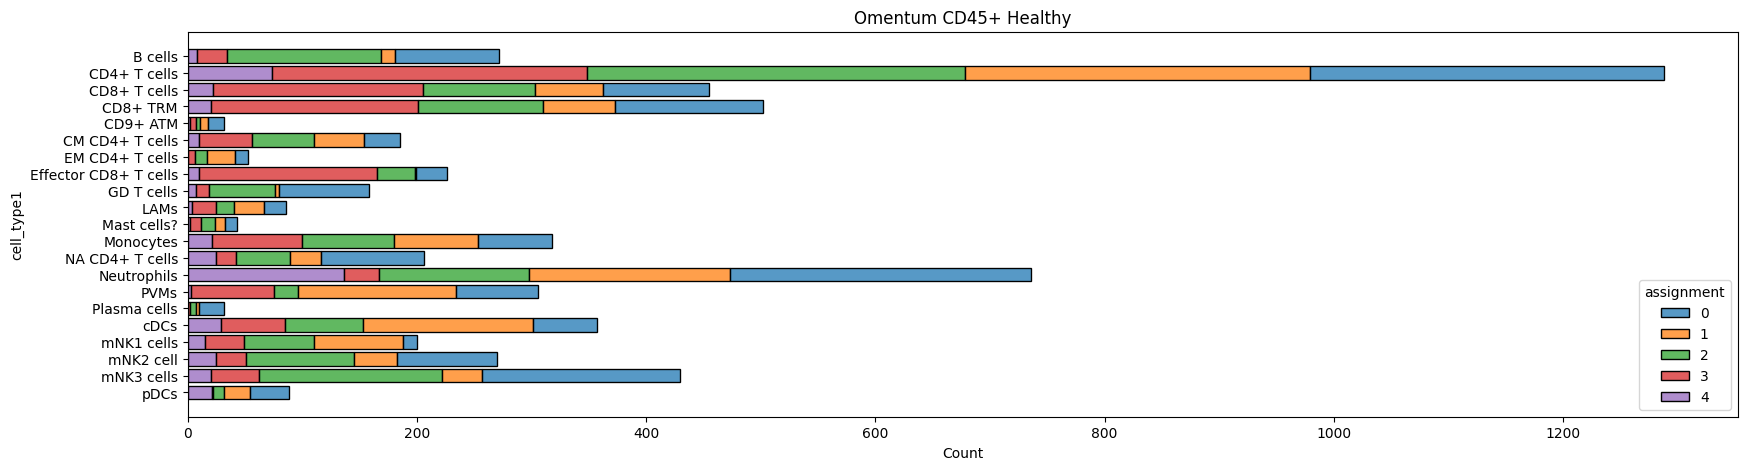

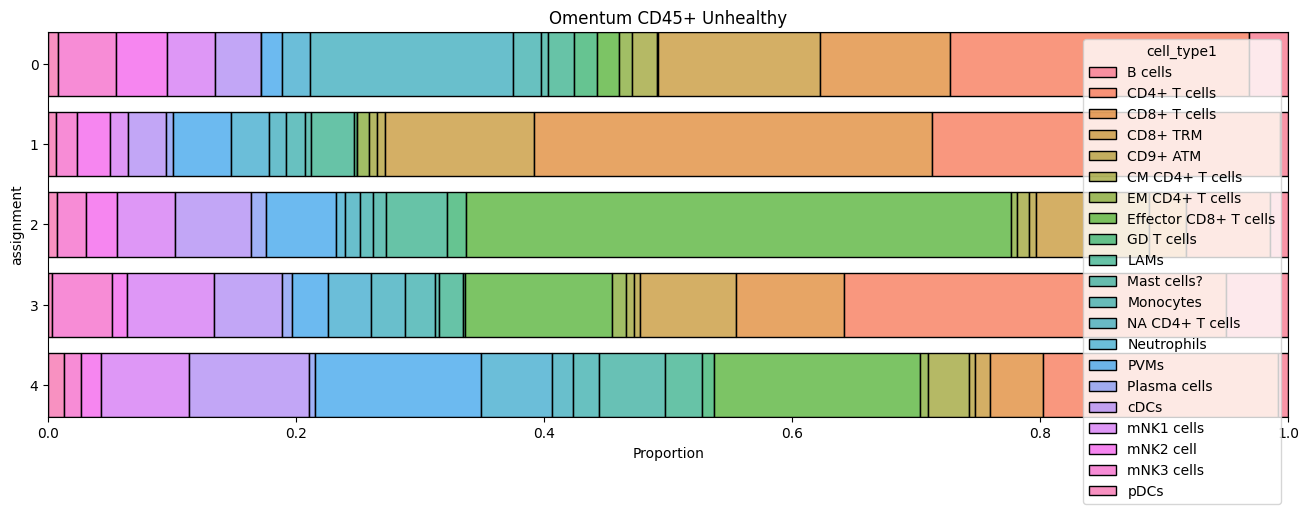

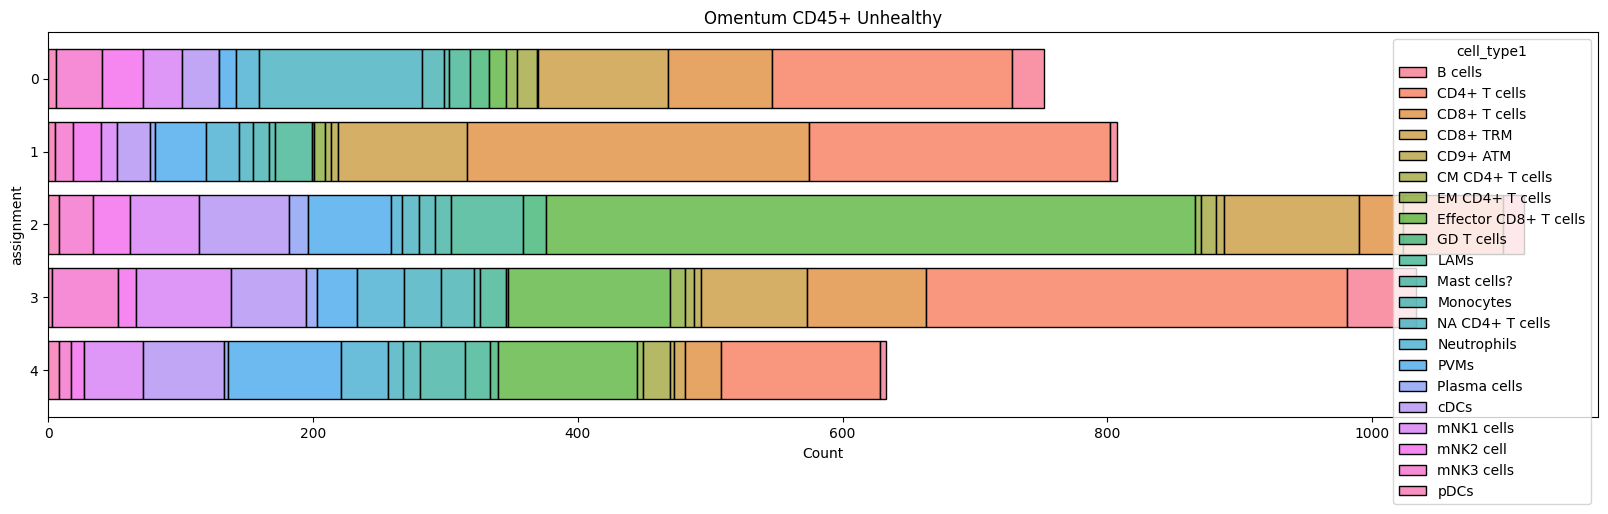

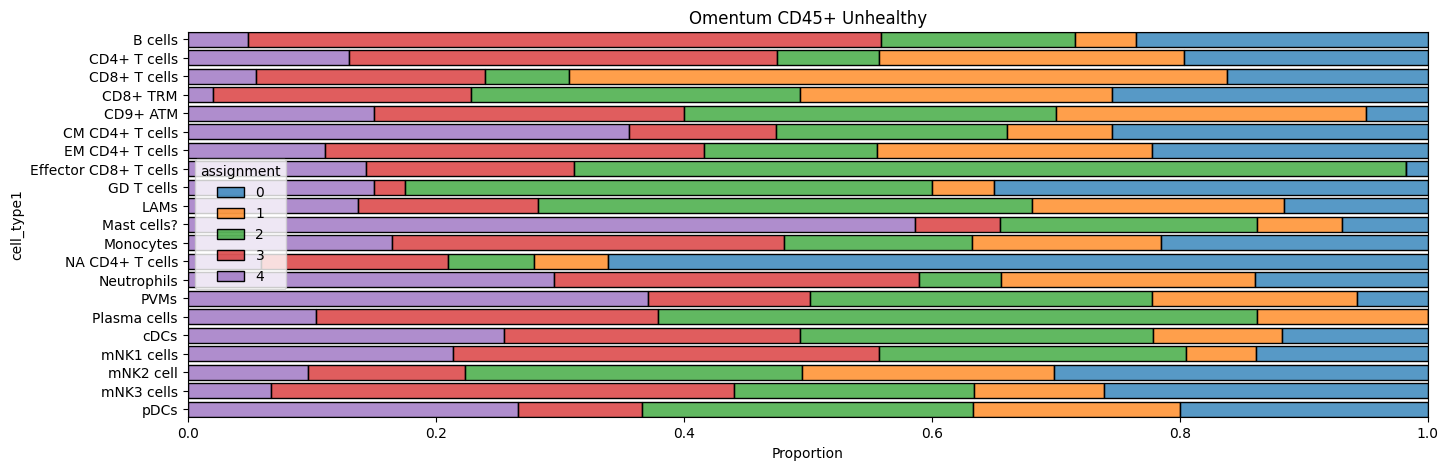

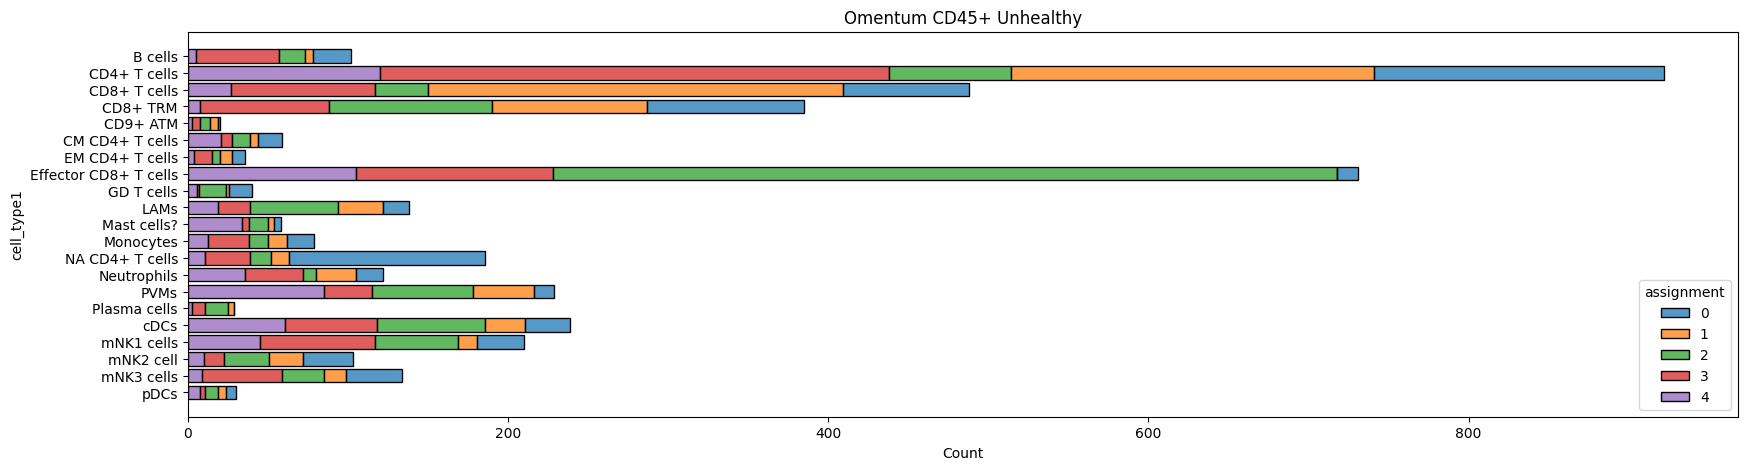

In [63]:
for disease in ["Healthy", "Unhealthy"]:
    
    adata = adata_45[adata_45.obs.disease == disease,:]
    title = f'{tissue} {disease}'
    
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue=hue,
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue=hue,
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y=hue, hue="assignment",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y=hue, hue="assignment",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

#### CD45-

In [64]:
adata_45_ = adata_all[adata_all.obs.cd45 == "neg",:]
hue = "cell_type1"
tissue = "Omentum CD45-"

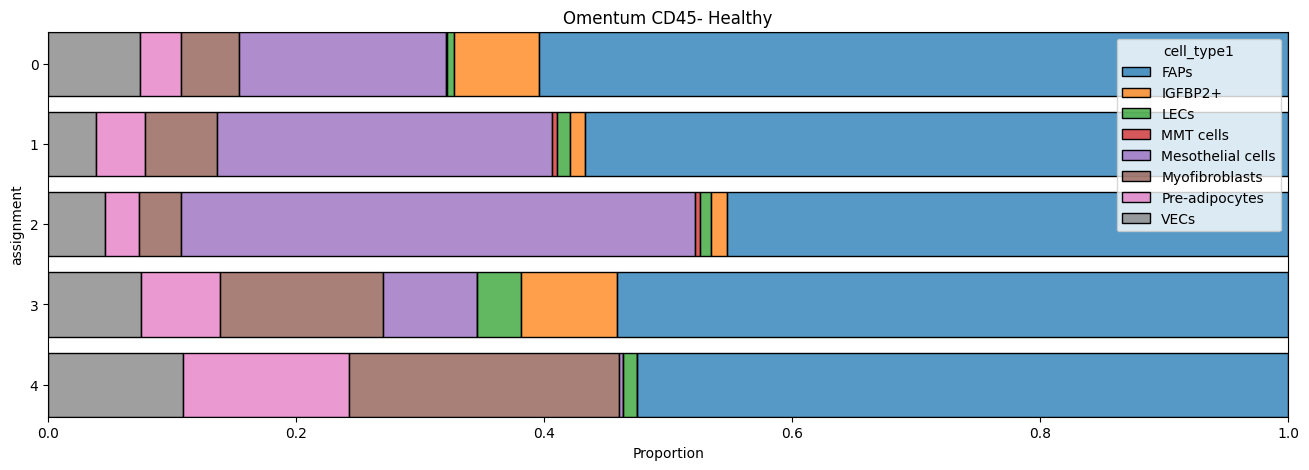

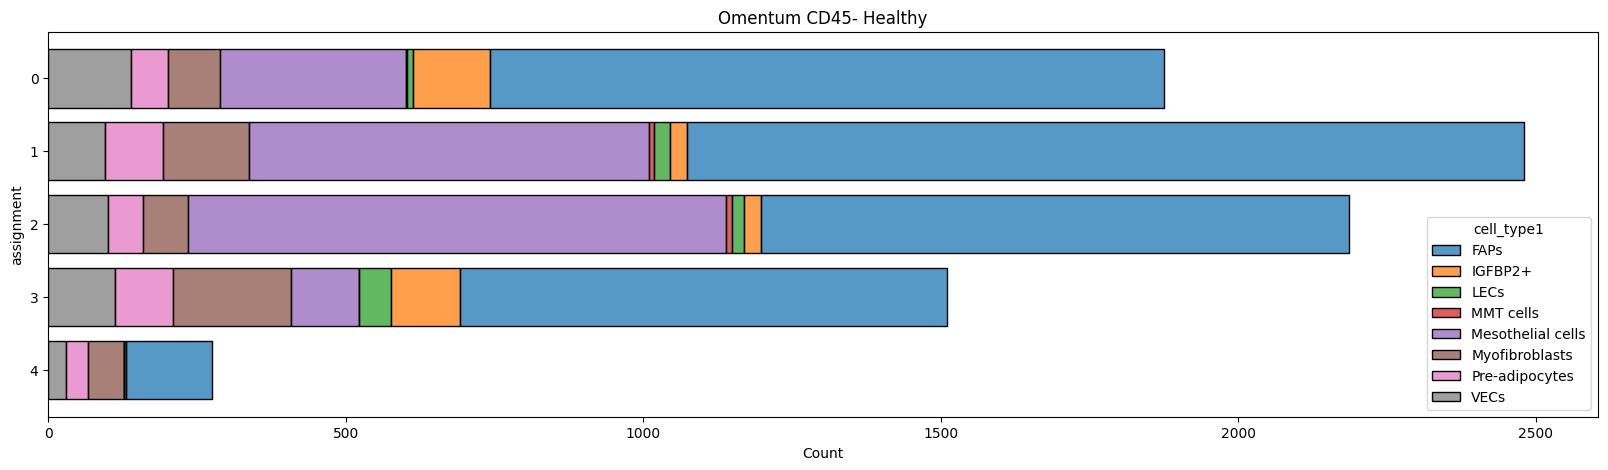

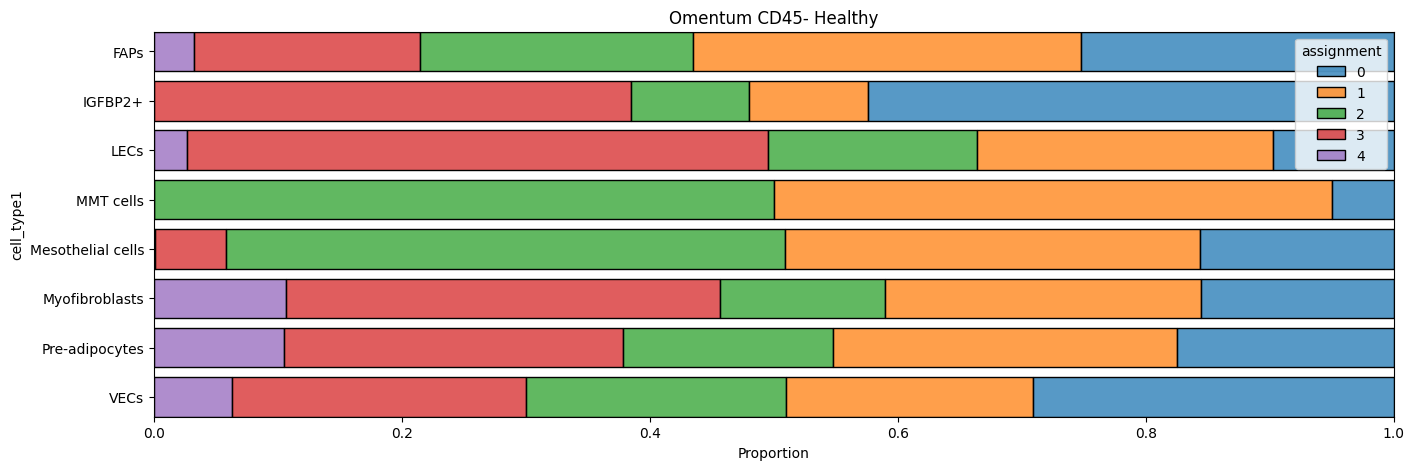

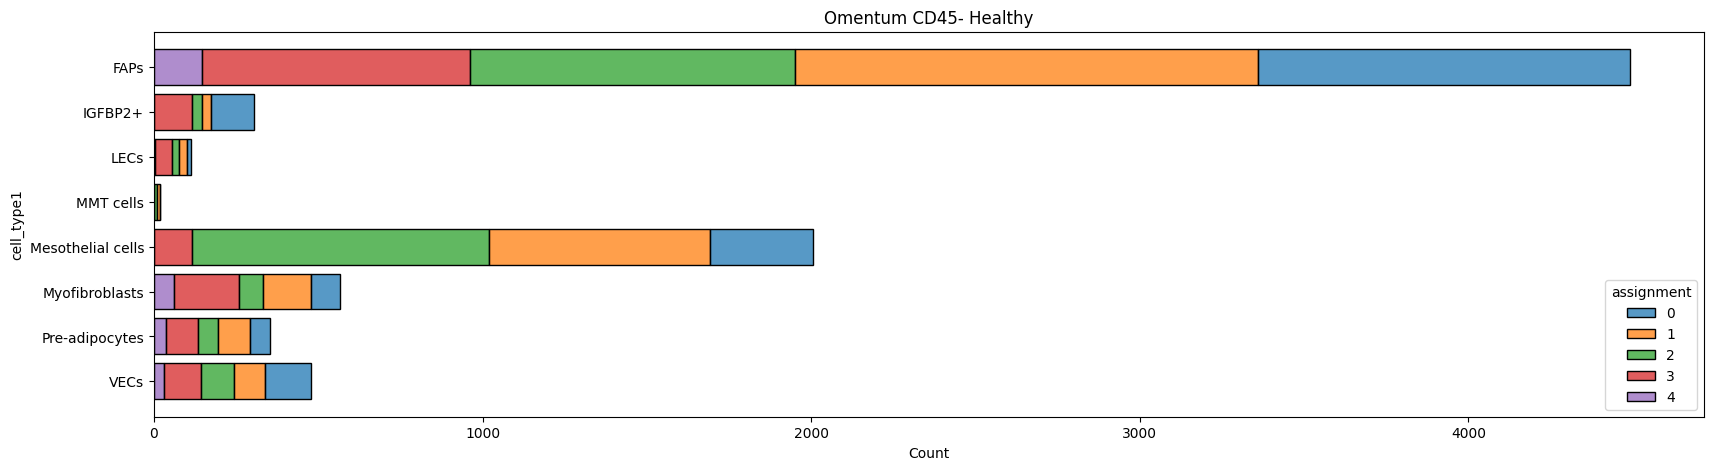

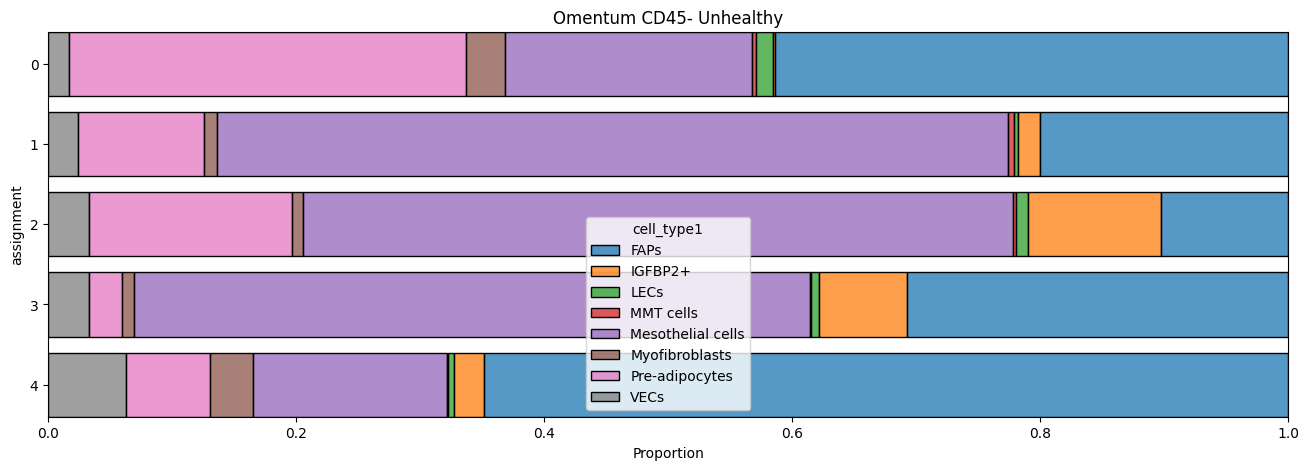

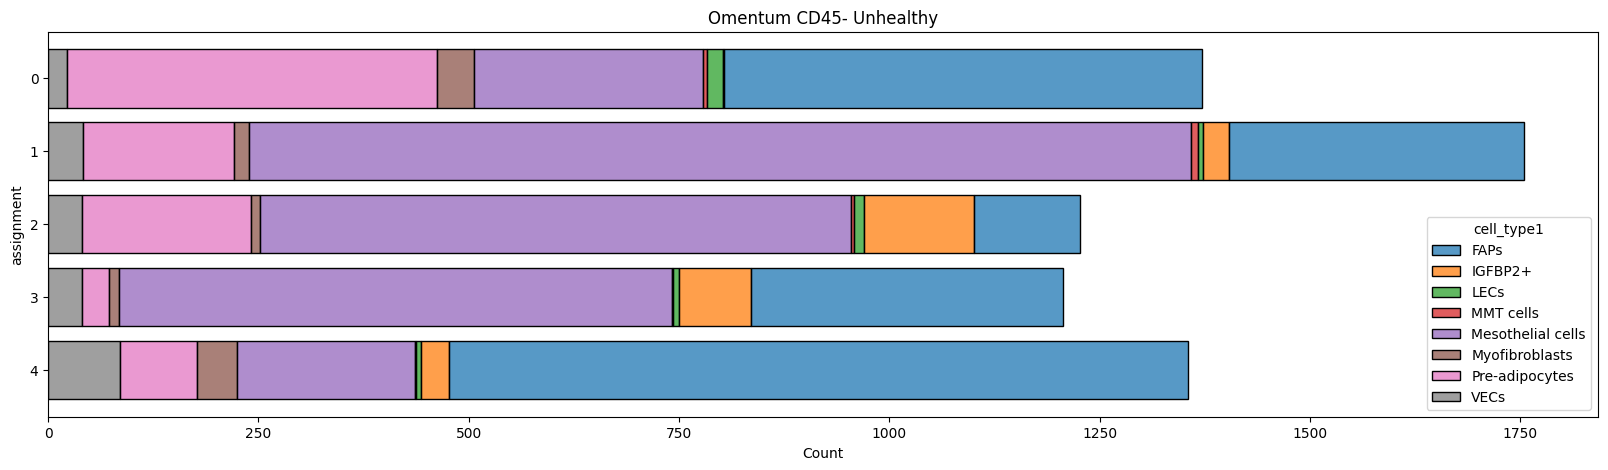

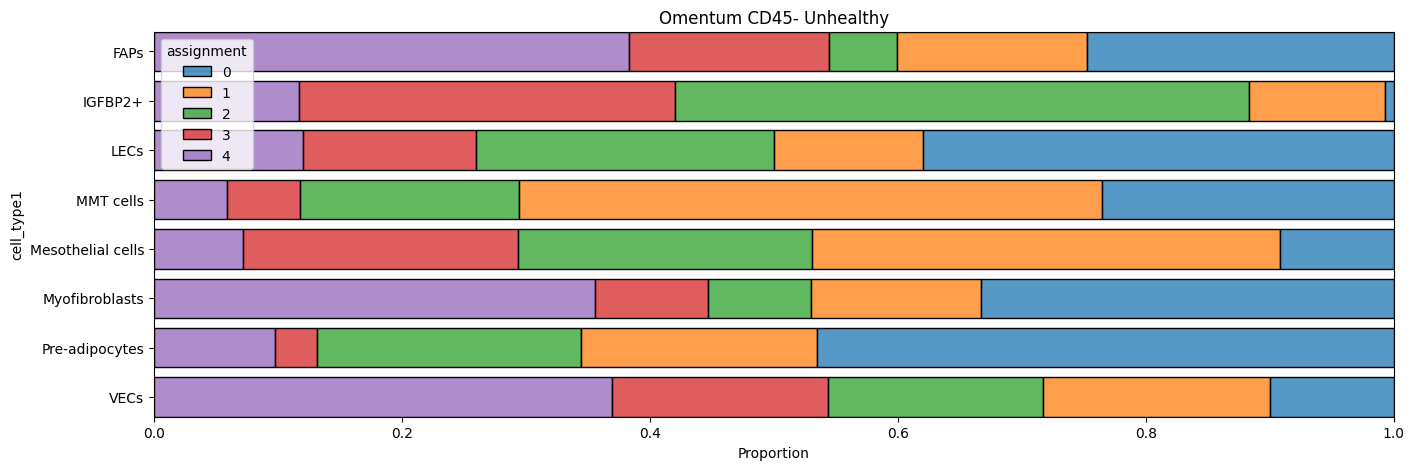

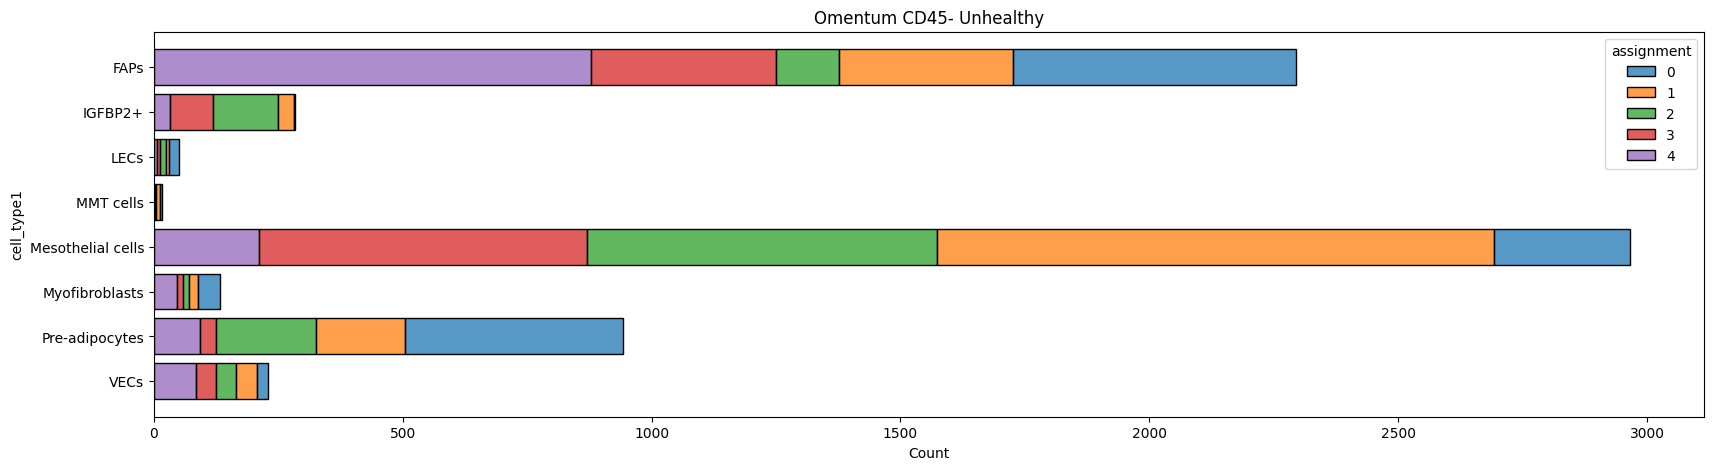

In [65]:
for disease in ["Healthy", "Unhealthy"]:
    
    adata = adata_45_[adata_45_.obs.disease == disease,:]
    title = f'{tissue} {disease}'
    
    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue=hue,
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y="assignment", hue=hue,
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(16, 5))
    sns.histplot(
        data=adata.obs,
        y=hue, hue="assignment",
        multiple="fill", stat="proportion",
        discrete=True, shrink=.8, 
        ax=ax
    )
    ax.set_title(title)
    plt.show()

    fig, ax = plt.subplots(figsize=(20, 5))
    sns.histplot(
        data=adata.obs,
        y=hue, hue="assignment",
        multiple="stack", stat="count",
        discrete=True, shrink=.8,
        ax=ax
    )
    ax.set_title(title)
    plt.show()